In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from joblib import load
import sys
from tqdm import tqdm
import random

# ensure local "src" package is importable
src_path = Path("../src").resolve()
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# import helpers used elsewhere (adjust names as needed)
try:
    from utils import (
        BASE_PROCESS, 
        ATOM_NUMBERS, 
        DESCRIPTORS, 
        SUPPORT,
        split_data,
    )
except Exception as e:
    raise ImportError(f"Failed to import from src/utils: {e}")

data = pd.read_csv("../Dataset/OCM-NguyenEtAl_with_descriptors.csv")
experiments_root = Path("../experiments/")
figures_root = Path("../experiments/figures/")
store_figures = True

TARGET_COL = "C2y"
ALL_FEATURES = BASE_PROCESS + ATOM_NUMBERS + DESCRIPTORS + SUPPORT
COLORS = sns.color_palette("tab10")
MANY_COLORS = sns.color_palette("husl", 12)
# compute colors for features
FEATURE_COLORS = {}
j = 4
for feature in ALL_FEATURES:
    if feature.startswith("M1"):
        FEATURE_COLORS[feature] = MANY_COLORS[0]
    elif feature.startswith("M2"):
        FEATURE_COLORS[feature] = MANY_COLORS[1]
    elif feature.startswith("M3"):
        FEATURE_COLORS[feature] = MANY_COLORS[2]
    elif feature.lower().startswith("support"):
        FEATURE_COLORS[feature] = MANY_COLORS[3]
    else:
        FEATURE_COLORS[feature] = MANY_COLORS[j]
        j += 1
# compute symbols for features
FEATURE_SYMBOLS = {}
for feature in ALL_FEATURES:
    if feature.endswith("atom_number"):
        FEATURE_SYMBOLS[feature] = "o"
    elif feature.endswith("mol%"):
        FEATURE_SYMBOLS[feature] = "s"
    elif feature.endswith("electronegativity"):
        FEATURE_SYMBOLS[feature] = "D"
    elif feature.endswith("ionization"):
        FEATURE_SYMBOLS[feature] = "^"
    elif feature.endswith("electron_count"):
        FEATURE_SYMBOLS[feature] = "X"
    elif feature.endswith("ionic_radius"):
        FEATURE_SYMBOLS[feature] = "v"
    elif feature.endswith("oxidation_state"):
        FEATURE_SYMBOLS[feature] = "P"
    elif feature.endswith("ID"):
        FEATURE_SYMBOLS[feature] = "o"
    elif feature.endswith("area"):
        FEATURE_SYMBOLS[feature] = "s"
    else:
        FEATURE_SYMBOLS[feature] = "o"

def load_gathered_results(experiment_path: Path) -> pd.DataFrame:
    #load data
    if not (experiment_path / "gathered_results.csv").exists():
        # go through all folders and load file "results_summary.csv" and concatenate them into a single dataframe
        all_results = get_results_csv(experiment_path)
        print(f"Found {len(all_results)} result files.")
        # concatenate all results
        results_df = pd.concat(all_results, ignore_index=True)
        # save gathered results
        results_df.to_csv(experiment_path / "gathered_results.csv", index=False)
    else:
        results_df = pd.read_csv(experiment_path / "gathered_results.csv")
    return results_df

def get_results_csv(experiment_path: Path) -> pd.DataFrame:
    if experiment_path.exists() and experiment_path.is_dir():
        result_file = experiment_path / "results_summary.csv"
        if result_file.exists():
            df_res = pd.read_csv(result_file)
            return [df_res]
        else:
            results = []
            for folder in experiment_path.iterdir():
                results.extend(get_results_csv(folder))
            return results
    else:
        return []

def load_feature_columns(feature_set: str) -> list:
    if feature_set == "base+descriptors":
        feature_cols = BASE_PROCESS + DESCRIPTORS
    elif feature_set == "base+atom_numbers+support":
        feature_cols = BASE_PROCESS + ATOM_NUMBERS + SUPPORT
    elif feature_set == "all":  # all features
        feature_cols = BASE_PROCESS + ATOM_NUMBERS + DESCRIPTORS + SUPPORT
    else:
        raise ValueError(f"Unknown feature set: {feature_set}")
    return feature_cols    

def get_mean_predictors(path: Path, results_df: pd.DataFrame, train_df: pd.DataFrame):
    n_training_catalysts = list(map(int, results_df["n_train_catalysts"].unique()))
    seeds = list(map(int, results_df["seed"].unique()))
    conditions = list(map(int, results_df["condition"].unique()))
    mean_predictors = {n: {condition: {} for condition in conditions} for n in n_training_catalysts}
    for n in n_training_catalysts:
        # find all split files for this n
        split_files = list((path / f"{n}/").glob("data_splits_*.joblib"))
        splits = {condition: {} for condition in conditions}
        for split_file in split_files:
            split_data = load(split_file)
            for condition in conditions:
                splits[condition].update(split_data[str(condition)])
        # now compute mean predictors for each condition for each seed
        for condition in conditions:
           for seed in seeds:
               mean_predictors[n][condition][seed] = float(train_df.iloc[splits[condition][seed]["train_indices"]][TARGET_COL].mean())
    return mean_predictors

def get_test_splits(path: Path, conditions=None, max_n_train_catalysts=49):
    # prepare dicts for gathering splits
    splits = {condition: {} for condition in (conditions if conditions is not None else [])}
    # gather splits for all seeds from all files
    # test samples are the same for all n_training_catalysts, load them from n=49
    split_files = list((path / f"{max_n_train_catalysts}/").glob("data_splits_*.joblib"))
    for split_file in split_files:
        split_data = load(split_file)
        if conditions is not None:
            for condition in conditions:
                splits[condition].update(split_data[str(condition)])
        else:
            splits.update(split_data)
    # now extract test indices
    if conditions is not None:
        test_splits = {}
        for condition in conditions:
            test_splits[condition] = {seed: splits[condition][seed]["test_indices"] for seed in splits[condition]}
    else:
        test_splits = {seed: splits[seed]["test_indices"] for seed in splits}
    return test_splits

def get_train_splits(path: Path, n_train_catalysts: int, conditions=None):
    # prepare dicts for gathering splits
    splits = {condition: {} for condition in (conditions if conditions is not None else [])}
    # gather splits from all files
    split_files = list((path / f"{n_train_catalysts}/").glob("data_splits_*.joblib"))
    for split_file in split_files:
        split_data = load(split_file)
        if conditions is not None:
            for condition in conditions:
                splits[condition].update(split_data[str(condition)])
        else:
            splits.update(split_data)
    # now extract train indices
    if conditions is not None:
        train_splits = {}
        for condition in conditions:
            train_splits[condition] = {seed: splits[condition][seed]["train_indices"] for seed in splits[condition]}
    else:
        train_splits = {seed: splits[seed]["train_indices"] for seed in splits}
    return train_splits



In [2]:
def plot_learning_curves(
        path: Path, 
        measure="mae", 
        ylim=(1.75, 3.25), 
        title="", 
        query=None, 
        split_strategy="catalyst",
        legend=True,
        skip_models=None,
):
    # load gathered results or gather and store them in a single data frame
    results_df = load_gathered_results(path)
    # combine n_train_catalysts and n_val_catalysts into a single column "n_train_catalysts" (sum of both)
    results_df["n_train_catalysts"] = results_df["n_train_catalysts"] + results_df["n_val_catalysts"]
    results_df = results_df.drop(columns=["n_val_catalysts"])
    if query is not None:
        results_df = results_df.query(query)
    n_seeds = results_df["seed"].nunique()
    n_test_catalysts = results_df["n_test_catalysts"].unique()
    # group by columns "model_type", "feature_set", "augmentation", "n_train_catalysts" and then compute mean and std over "seed"
    res = results_df.groupby(["model_type", "feature_set", "augmentation", "n_train_catalysts"])[measure].agg(["mean", "std"]).reset_index()
    colors = {
        "base+descriptors": COLORS[0],
        "base+atom_numbers+support": COLORS[1],
        "all": COLORS[2],
    }
    labels = {
        ("base+descriptors", "yes"): "Descriptors, augmented",
        ("base+descriptors", "no"): "Descriptors",
        ("base+atom_numbers+support", "yes"): "Atom Numbers, augmented",
        ("base+atom_numbers+support", "no"): "Atom Numbers",
        ("all", "yes"): "All features, augmented",
        ("all", "no"): "All features",
    }
    plt.figure(figsize=(5, 3))
    res_list = list(res.groupby(["model_type", "feature_set", "augmentation"]))
    model_type = res_list[0][0][0]  # get model type from first group
    res_dict = {key: group for (key, group) in res_list}
    ordered_combinations = [
        (model_type, "base+atom_numbers+support", "no"),
        (model_type, "base+atom_numbers+support", "yes"),
        (model_type, "base+descriptors", "no"),
        (model_type, "base+descriptors", "yes"),
        (model_type, "all", "no"),
        (model_type, "all", "yes"),
    ]
    err_bar_handles = []
    for (model_type, feature_set, augmentation) in ordered_combinations:
        if skip_models is not None and (model_type, feature_set, augmentation) in skip_models:
            continue
        group = res_dict[(model_type, feature_set, augmentation)]
        if augmentation == "no":
            label = labels[(feature_set, augmentation)]
        else:
            label = None
        linestyle = '--' if augmentation == "yes" else '-'
        marker = 'o'
        color = colors[feature_set]
        handle = plt.errorbar(group["n_train_catalysts"], group["mean"], yerr=group["std"], label=label, capsize=5, marker=marker, linestyle=linestyle, color=color, linewidth=1)
        if augmentation == "no":
            err_bar_handles.append(handle)
    if legend:
        # add two legends, one with feature sets and one with explanation of augmentation
        leg = plt.legend(handles=err_bar_handles, loc="upper right", title="Feature Set")
        handles_aug = [
            plt.Line2D([], [], color='black', linestyle='--', label='Yes'),
            plt.Line2D([], [], color='black', linestyle='-', label='No'),
        ]
        # add slightly offset to the augmentation legend to avoid overlap with the error bars
        plt.legend(handles=handles_aug, title="Augmentation", loc="upper center", bbox_to_anchor=(0.47, 1.0))
        plt.gca().add_artist(leg) # add previous legend back
    plt.xlabel("Number of Training Catalysts")
    plt.ylabel(f"{measure.upper()} (C$_2$ Yield)")
    if split_strategy == "catalyst":
        # plt.title(title + f" ({n_seeds} seeds, {n_test_catalysts[0]} test catalysts)")
        print(f"Plotting learning curve for {n_seeds} seeds, {n_test_catalysts[0]} test catalysts.")
    else:
        # plt.title(title + f" ({n_seeds} seeds, 80%/20% train/test split)")
        print(f"Plotting learning curve for {n_seeds} seeds, 80%/20% train/test split.")
    plt.grid(True, linestyle=':')
    plt.ylim(ylim)
    plt.xlim(-2, 52)
    plt.tight_layout()
    # store figure
    def _fm(s):
        return s.replace(" ", "_").lower()
    if store_figures:
        plt.savefig(
            figures_root / 
            f"learning_curve_{_fm(title)}_{_fm(split_strategy)}_{_fm(measure)}.png"
        )
    # show figure
    plt.show()
    return

def plot_learning_curves_conditions(
        path: Path, 
        measure="mae", 
        ylim=(1.75, 3.25), 
        title="", 
        query=None, 
        split_strategy="catalyst",
        condition_name="Condition",
        train_df=None,
        single_plot_model=None,
):
    # load data
    results_df = load_gathered_results(path)
    # update test catalysts info if missing
    if "all_mae" not in results_df.columns:
        results_df, test_catalysts = find_and_update_test_catalysts(results_df)
        results_df.to_csv(path / "gathered_results.csv", index=False)
    # update r2 values if missing
    if measure == "r2" and "all_r2" not in results_df.columns:
        # the r2 has not been computed correctly before, recompute it here
        results_df = update_r2(path, results_df, data)
        results_df.to_csv(path / "gathered_results.csv", index=False)
    
    # combine n_train_catalysts and n_val_catalysts into a single column "n_train_catalysts" (sum of both)
    results_df["n_train_catalysts"] = results_df["n_train_catalysts"] + results_df["n_val_catalysts"]
    results_df = results_df.drop(columns=["n_val_catalysts"])
    if query is not None:
        results_df = results_df.query(query)
    n_seeds = results_df["seed"].nunique()
    n_test_catalysts = results_df["n_test_catalysts"].unique()
    
    # plot learning curve per condition
    # first define colors and labels
    colors = {
        "base+descriptors": COLORS[0],
        "base+atom_numbers+support": COLORS[1],
        "all": COLORS[2],
    }
    labels = {
        ("base+descriptors", "yes"): "Descriptors, augmented",
        ("base+descriptors", "no"): "Descriptors",
        ("base+atom_numbers+support", "yes"): "Atom Numbers, augmented",
        ("base+atom_numbers+support", "no"): "Atom Numbers",
        ("all", "yes"): "All features, augmented",
        ("all", "no"): "All features",
    }
    xlabel = f"Number of Training Catalysts with Data from Target {condition_name}"
    # prepare composite figure with subplots
    conditions = results_df["condition"].unique()
    n_conditions = len(conditions)
    n_rows = (n_conditions // 2) + (n_conditions % 2)
    fig, axs = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows), sharey=True, sharex=True)
    if split_strategy == "catalyst":
        fig.suptitle(title + f" ({n_seeds} seeds, {n_test_catalysts[0]} test catalysts)", fontsize=14)
    else:
        fig.suptitle(title + f" ({n_seeds} seeds, 80%/20% train/test split)", fontsize=14)
    fig.tight_layout(rect=[0, 0, 1, 0.99])  # reserve top 5% for the suptitle
    if n_rows > 1:
        axs = axs.flatten()
    if n_conditions % 2 == 0:
        for ax in axs[-2:]:
            ax.set_xlabel(xlabel)
    else:
        axs[-1].set_xlabel(xlabel)
    # plot each condition
    for i, (group_name, group_df) in enumerate(results_df.groupby("condition")):
        ax = axs[i]
        # group by columns "model_type", "feature_set", "augmentation", "n_train_catalysts" and then compute mean and std over "seed"
        res = group_df.groupby(["model_type", "feature_set", "augmentation", "n_train_catalysts"])[measure].agg(["mean", "std"]).reset_index()
        res_list = list(res.groupby(["model_type", "feature_set", "augmentation"]))
        model_type = res_list[0][0][0]  # get model type from first group
        res_dict = {key: group for (key, group) in res_list}
        ordered_combinations = [
            (model_type, "base+atom_numbers+support", "no"),
            (model_type, "base+atom_numbers+support", "yes"),
            (model_type, "base+descriptors", "no"),
            (model_type, "base+descriptors", "yes"),
            (model_type, "all", "no"),
            (model_type, "all", "yes"),
        ]
        for (model_type, feature_set, augmentation) in ordered_combinations:
            group = res_dict[(model_type, feature_set, augmentation)]
            if augmentation == "no":
                label = labels[(feature_set, augmentation)]
            else:
                label = None
            linestyle = '--' if augmentation == "yes" else '-'
            marker = 'o'
            color = colors[feature_set]
            ax.errorbar(group["n_train_catalysts"], group["mean"], yerr=group["std"], label=label, capsize=5, marker=marker, linestyle=linestyle, color=color, linewidth=1)
        if i == 1 or (n_conditions == 1 and i == 0):
            # add legend with explanation of augmentation
            ax.plot([], [], color='black', linestyle='-', label='Regular')
            ax.plot([], [], color='black', linestyle='--', label='Augmented')
            ax.legend()
        ax.set_title(f"Condition: {group_name}", loc='left')
        ax.grid(True, linestyle=':')
        ax.set_ylim(ylim)
        ax.set_xlim(-2, 52)
        if i % 2 == 0:
            ax.set_ylabel(f"{measure.upper()} (C$_2$ yield)")
    # store figure
    def _fm(s):
        return s.replace(" ", "_").replace("$_", "").replace("$", "").replace(",", "").replace("/", "-").lower()
    if store_figures:
        plt.savefig(
            figures_root / 
            f"all_learning_curves_{_fm(condition_name)}_{_fm(title)}_{_fm(split_strategy)}_{_fm(measure)}.png"
        )
    # show figure
    plt.show()
    if single_plot_model:
        # plot single plot for specific model
        fig, ax = plt.subplots(figsize=(5.2, 3.5))
        res = results_df[
            (results_df["feature_set"] == single_plot_model[0]) & 
            (results_df["augmentation"] == single_plot_model[1])
        ].groupby(["n_train_catalysts", "condition"])[measure].agg(["mean", "std"]).reset_index()
        handles_xgb = []
        for i, (condition, group) in enumerate(res.groupby("condition")):
            handle = plt.errorbar(group["n_train_catalysts"], group["mean"], yerr=group["std"], label=condition, capsize=5, marker='o', linestyle='-', linewidth=1, color=COLORS[i])
            handles_xgb.append(handle)
        legend = ax.legend(handles=handles_xgb, title=f"{condition_name}", loc="upper right")
        # compute and plot mean predictor baseline if train_df is given
        if train_df is not None and measure == "mae":
            mean_predictors = get_mean_predictors(path, results_df, train_df)
            test_splits = get_test_splits(path, conditions=conditions)
            for i, (condition, group) in enumerate(res.groupby("condition")):
                mean_vals = np.zeros((len(group["n_train_catalysts"]), n_seeds))
                for j, n_train in enumerate(group["n_train_catalysts"]):
                    for k, seed in enumerate(results_df["seed"].unique()):
                        mean_val = mean_predictors[n_train][condition][seed]
                        test_indices = test_splits[condition][seed]
                        test_targets = train_df.iloc[test_indices][TARGET_COL].values
                        mean_vals[j, k] = np.mean(np.abs(test_targets - mean_val))
                mean_mae = np.mean(mean_vals, axis=1)
                plt.plot(group["n_train_catalysts"], mean_mae, linestyle='--', color=COLORS[i])
            handles_mean = [
                plt.Line2D([], [], color='black', linestyle='--', label='Mean Predictor'),
                plt.Line2D([], [], color='black', linestyle='-', label='XGBoost'),
            ]
            plt.legend(handles=handles_mean, title="Model", loc="upper center")
            ax.add_artist(legend) # add previous legend back
        # finalize single plot with legend and labels
        plt.xlabel(xlabel)
        plt.ylabel(f"{measure.upper()} (C$_2$ Yield)")
        if split_strategy == "catalyst":
            # plt.title(title + f" ({n_seeds} seeds, {n_test_catalysts[0]} test catalysts)")
            print(f"Plotting learning curve for {n_seeds} seeds, {n_test_catalysts[0]} test catalysts.")
        else:
            # plt.title(title + f" ({n_seeds} seeds, 80%/20% train/test split)")
            print(f"Plotting learning curve for {n_seeds} seeds, 80%/20% train/test split.")
        plt.grid(True, linestyle=':')
        plt.ylim(ylim)
        plt.xlim(-2, 52)
        plt.tight_layout()
        # store figure
        if store_figures:
            plt.savefig(
                figures_root / 
                f"learning_curve_{_fm(condition_name)}_{_fm(title)}_{_fm(split_strategy)}_{_fm(measure)}_{_fm(labels[single_plot_model])}.png"
            )
        # show figure
        plt.show()
    return

### Learning curves when increasing training volume
##### 1. Splitting training and test data randomly (like in previous papers)

Plotting learning curve for 20 seeds, 80%/20% train/test split.


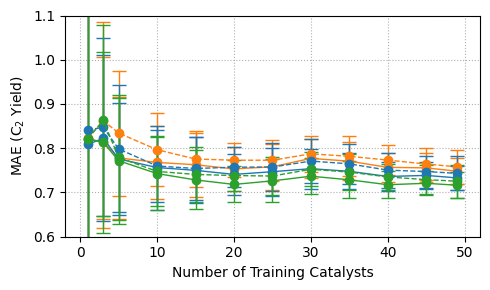

Plotting learning curve for 20 seeds, 80%/20% train/test split.


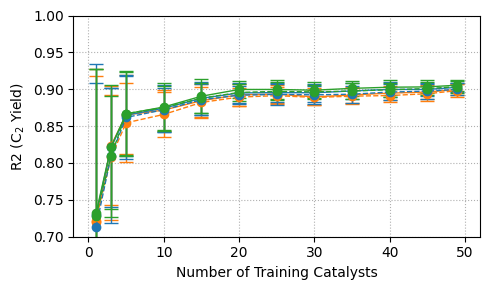

In [6]:
query = None
root = experiments_root / "split_random"
split_strategy = "catalyst_random"
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="mae", 
    ylim=(0.6, 1.1), 
    title="XGBoost", 
    query=query,
    split_strategy=split_strategy,
    legend=False,
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="r2", 
    ylim=(0.7, 1.0), 
    title="XGBoost", 
    query=query,
    split_strategy=split_strategy,
    legend=False,
)

##### 2. Split by catalyst names

Plotting learning curve for 100 seeds, 10 test catalysts.


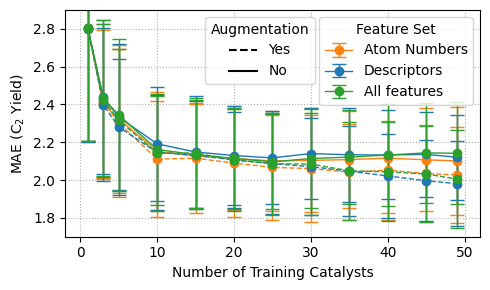

Plotting learning curve for 100 seeds, 10 test catalysts.


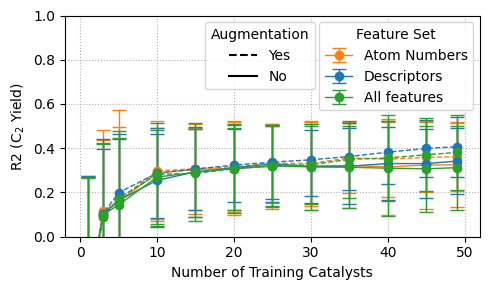

Plotting learning curve for 100 seeds, 10 test catalysts.


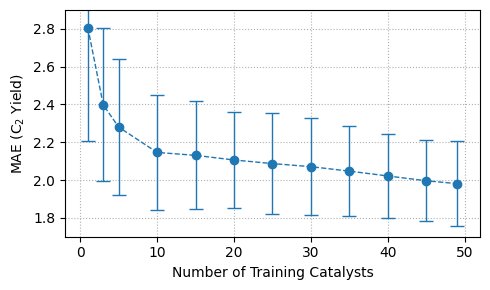

Plotting learning curve for 100 seeds, 10 test catalysts.


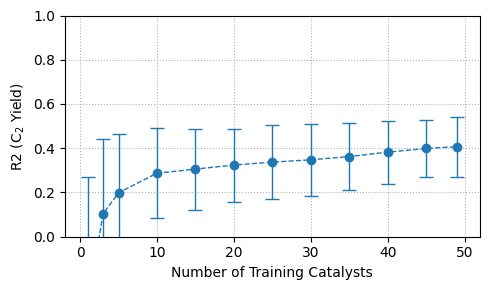

Plotting learning curve for 100 seeds, 10 test catalysts.


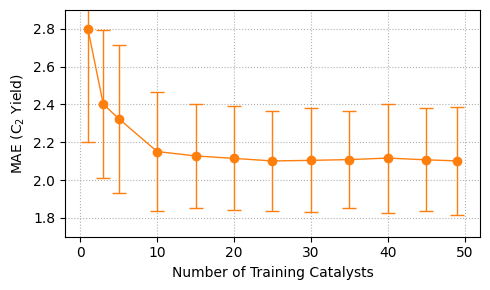

Plotting learning curve for 100 seeds, 10 test catalysts.


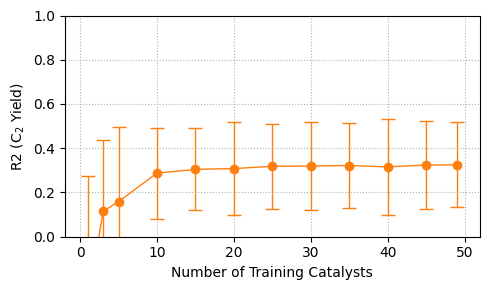

Plotting learning curve for 100 seeds, 10 test catalysts.


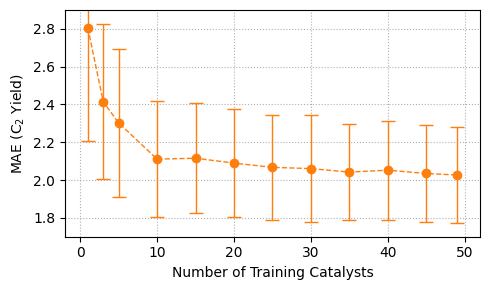

Plotting learning curve for 100 seeds, 10 test catalysts.


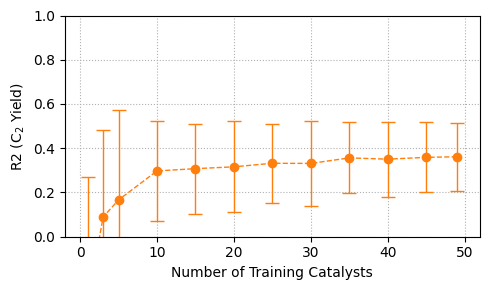

In [7]:
query = None
root = experiments_root / "split_catalyst"
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="mae", 
    ylim=(1.7, 2.9), 
    title="XGBoost", 
    query=query
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="r2", 
    ylim=(0.0, 1.0), 
    title="XGBoost", 
    query=query
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="mae", 
    ylim=(1.7, 2.9), 
    title="DescAug", 
    query=query,
    skip_models=[
        ("xgboost", "base+atom_numbers+support", "no"),
        ("xgboost", "base+atom_numbers+support", "yes"),
        ("xgboost", "base+descriptors", "no"),
        ("xgboost", "all", "no"),
        ("xgboost", "all", "yes"),
    ],
    legend=False,
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="r2", 
    ylim=(0.0, 1.0), 
    title="DescAug", 
    query=query,
    skip_models=[
        ("xgboost", "base+atom_numbers+support", "no"),
        ("xgboost", "base+atom_numbers+support", "yes"),
        ("xgboost", "base+descriptors", "no"),
        ("xgboost", "all", "no"),
        ("xgboost", "all", "yes"),
    ],
    legend=False,
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="mae", 
    ylim=(1.7, 2.9), 
    title="AtomSup", 
    query=query,
    skip_models=[
        ("xgboost", "base+atom_numbers+support", "yes"),
        ("xgboost", "base+descriptors", "no"),
        ("xgboost", "base+descriptors", "yes"),
        ("xgboost", "all", "no"),
        ("xgboost", "all", "yes"),
    ],
    legend=False,
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="r2", 
    ylim=(0.0, 1.0), 
    title="AtomSup", 
    query=query,
    skip_models=[
        ("xgboost", "base+atom_numbers+support", "yes"),
        ("xgboost", "base+descriptors", "no"),
        ("xgboost", "base+descriptors", "yes"),
        ("xgboost", "all", "no"),
        ("xgboost", "all", "yes"),
    ],
    legend=False,
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="mae", 
    ylim=(1.7, 2.9), 
    title="AtomSupAug", 
    query=query,
    skip_models=[
        ("xgboost", "base+atom_numbers+support", "no"),
        ("xgboost", "base+descriptors", "no"),
        ("xgboost", "base+descriptors", "yes"),
        ("xgboost", "all", "no"),
        ("xgboost", "all", "yes"),
    ],
    legend=False,
)
plot_learning_curves(
    root / "xgb_cv_random_50", 
    measure="r2", 
    ylim=(0.0, 1.0), 
    title="AtomSupAug", 
    query=query,
    skip_models=[
        ("xgboost", "base+atom_numbers+support", "no"),
        ("xgboost", "base+descriptors", "no"),
        ("xgboost", "base+descriptors", "yes"),
        ("xgboost", "all", "no"),
        ("xgboost", "all", "yes"),
    ],
    legend=False,
)

##### 3. Split by held-out temperature values

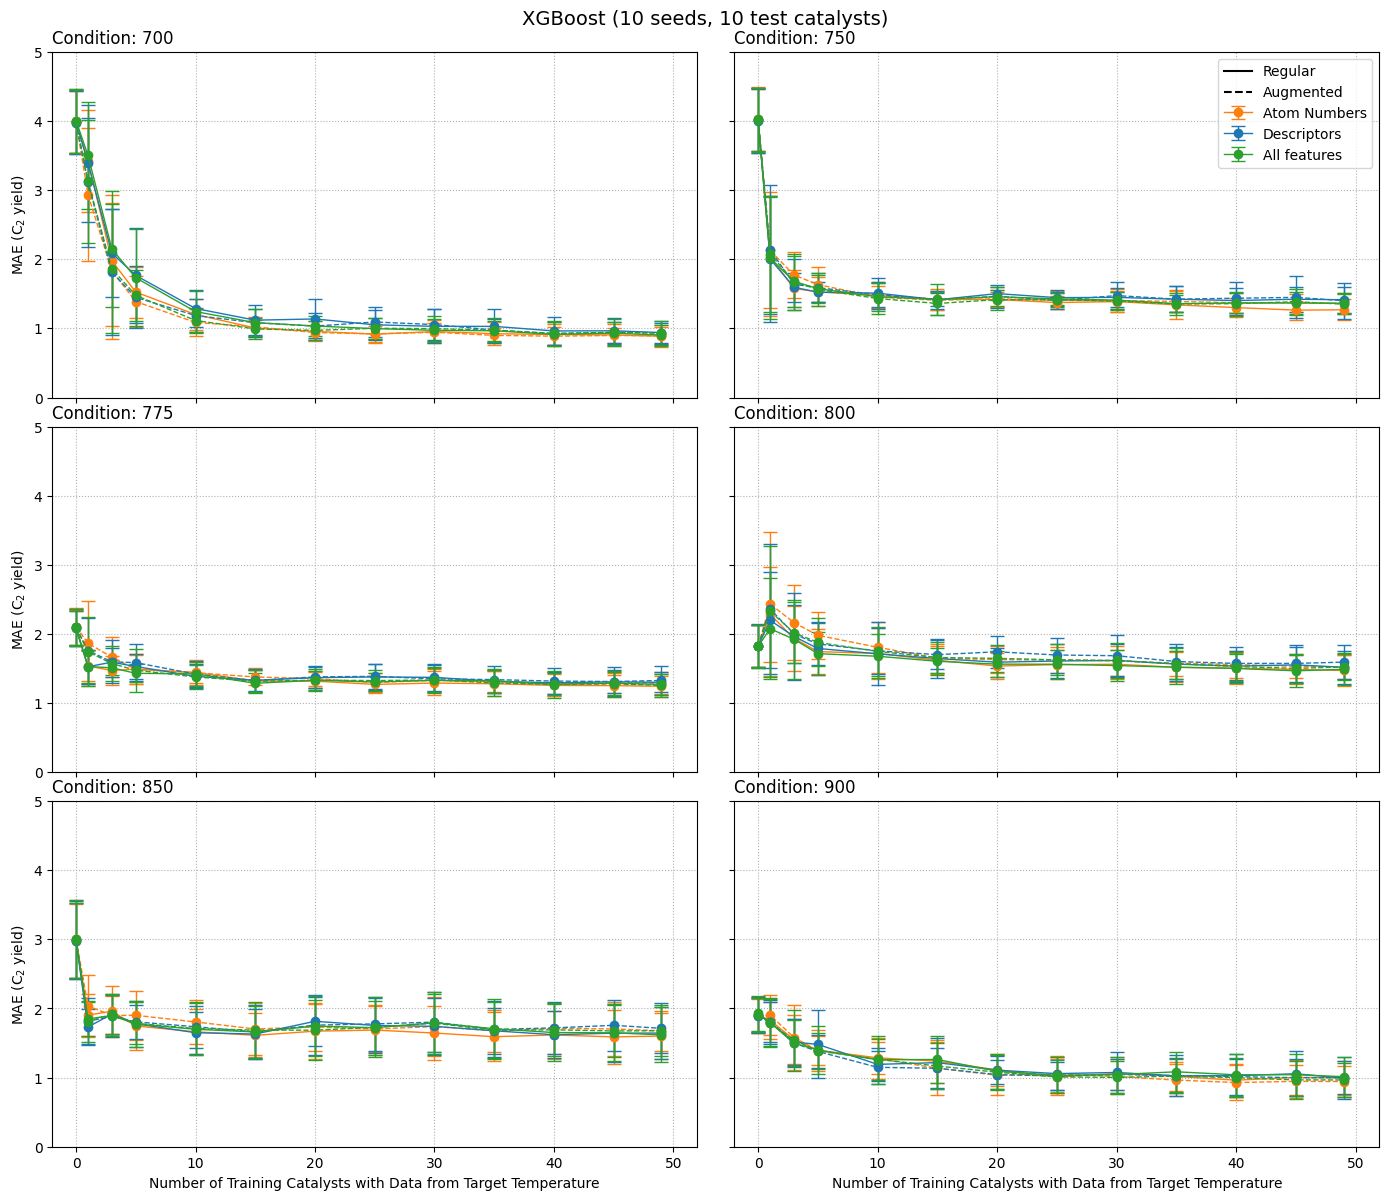

Plotting learning curve for 10 seeds, 10 test catalysts.


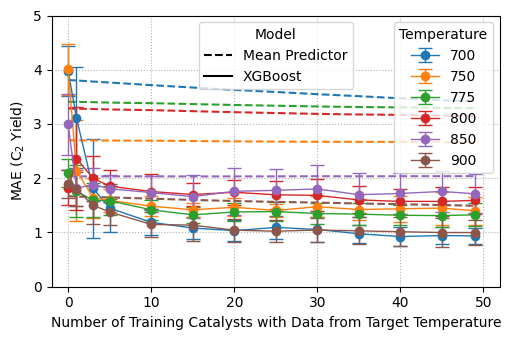

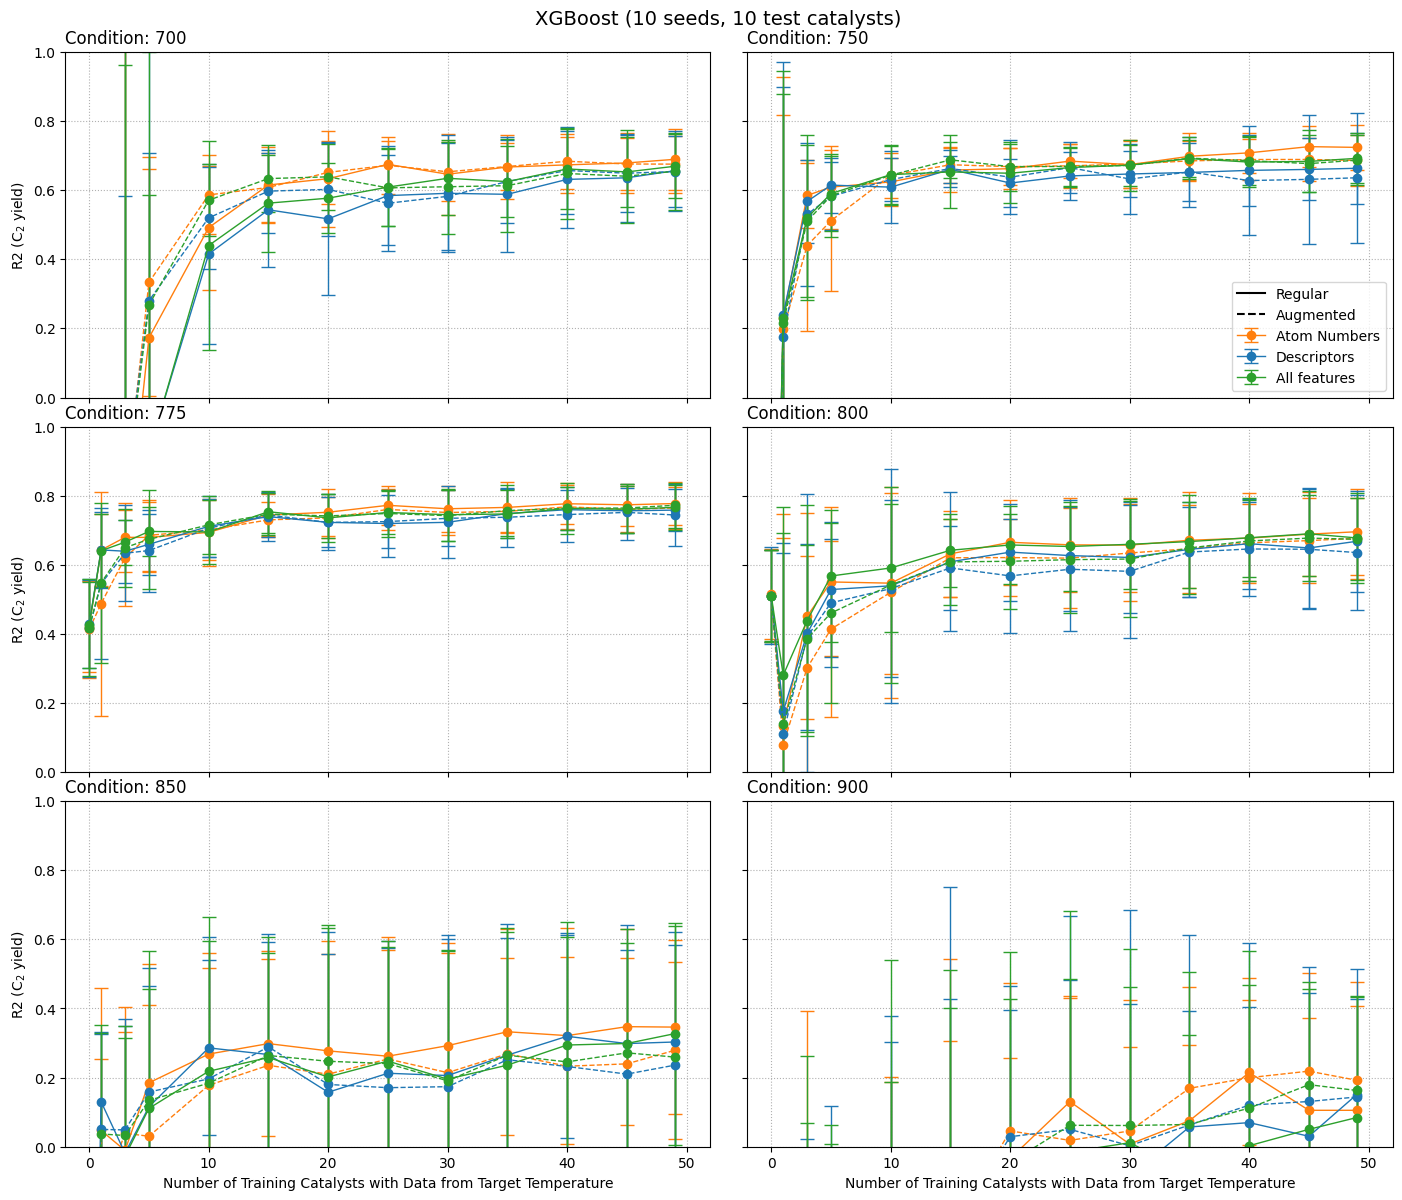

Plotting learning curve for 10 seeds, 10 test catalysts.


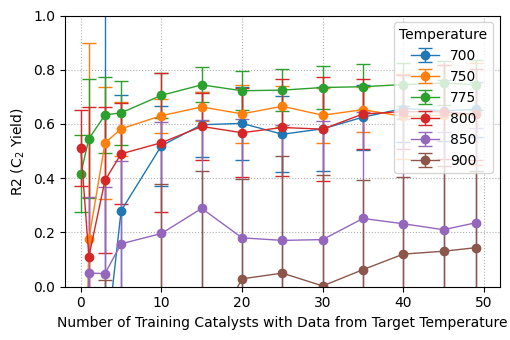

In [8]:
query = None
root = experiments_root / "temperature"
plot_learning_curves_conditions(
    root / "xgb_cv_random_50", 
    measure="mae", 
    ylim=(0.0, 5.0), 
    title="XGBoost", 
    query=query,
    split_strategy="catalyst",
    condition_name="Temperature",
    train_df=data,
    single_plot_model=("base+descriptors", "yes"),
)
plot_learning_curves_conditions(
    root / "xgb_cv_random_50", 
    measure="r2", 
    ylim=(0.0, 1.0), 
    title="XGBoost", 
    query=query,
    split_strategy="catalyst",
    condition_name="Temperature",
    train_df=data,
    single_plot_model=("base+descriptors", "yes"),
)

##### 4. Split by held-out CH4/O2 ratio values

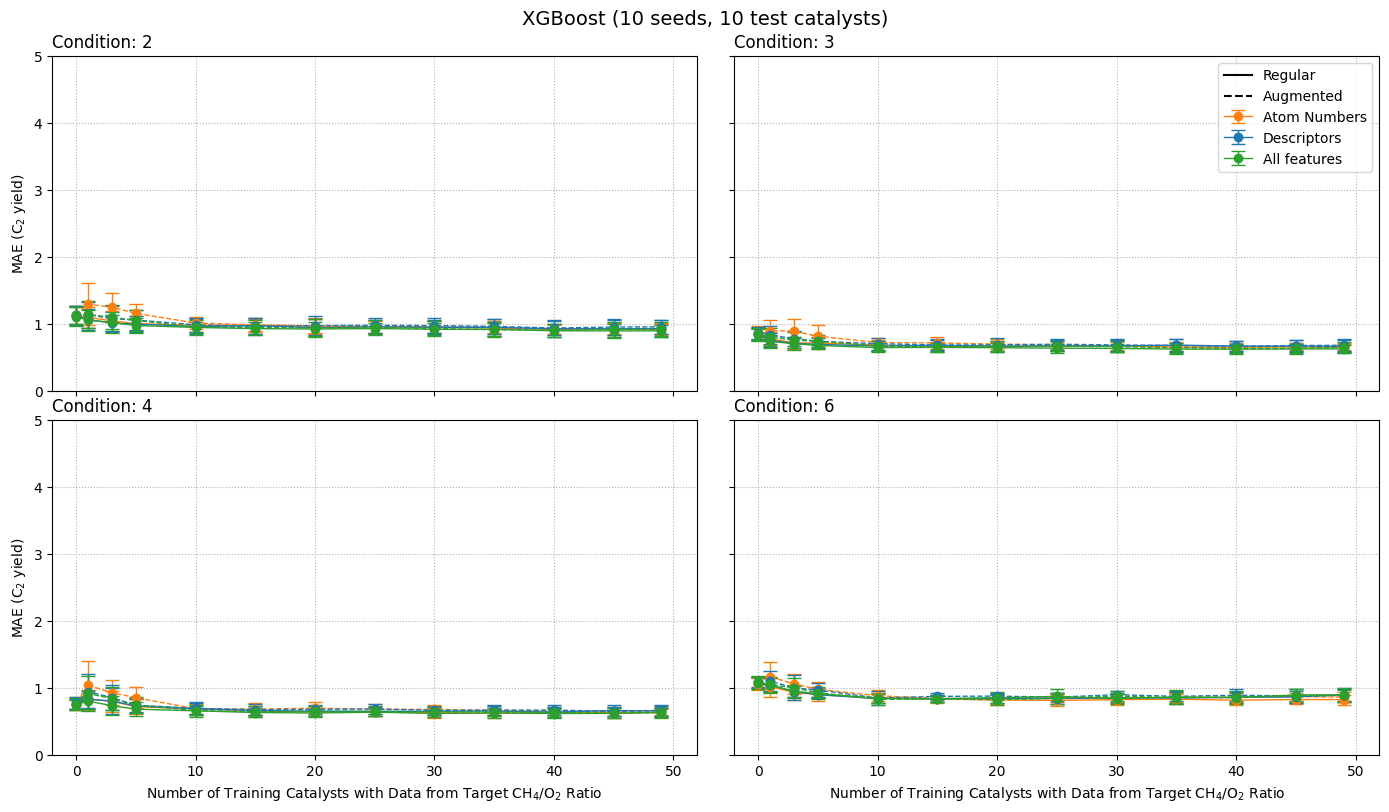

Plotting learning curve for 10 seeds, 10 test catalysts.


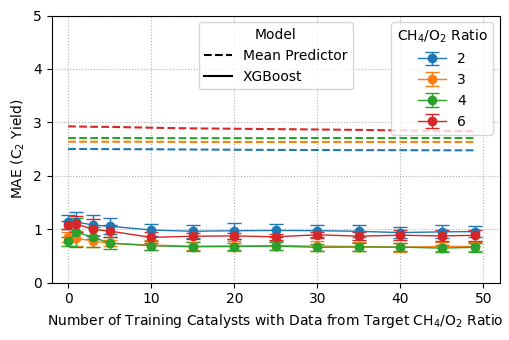

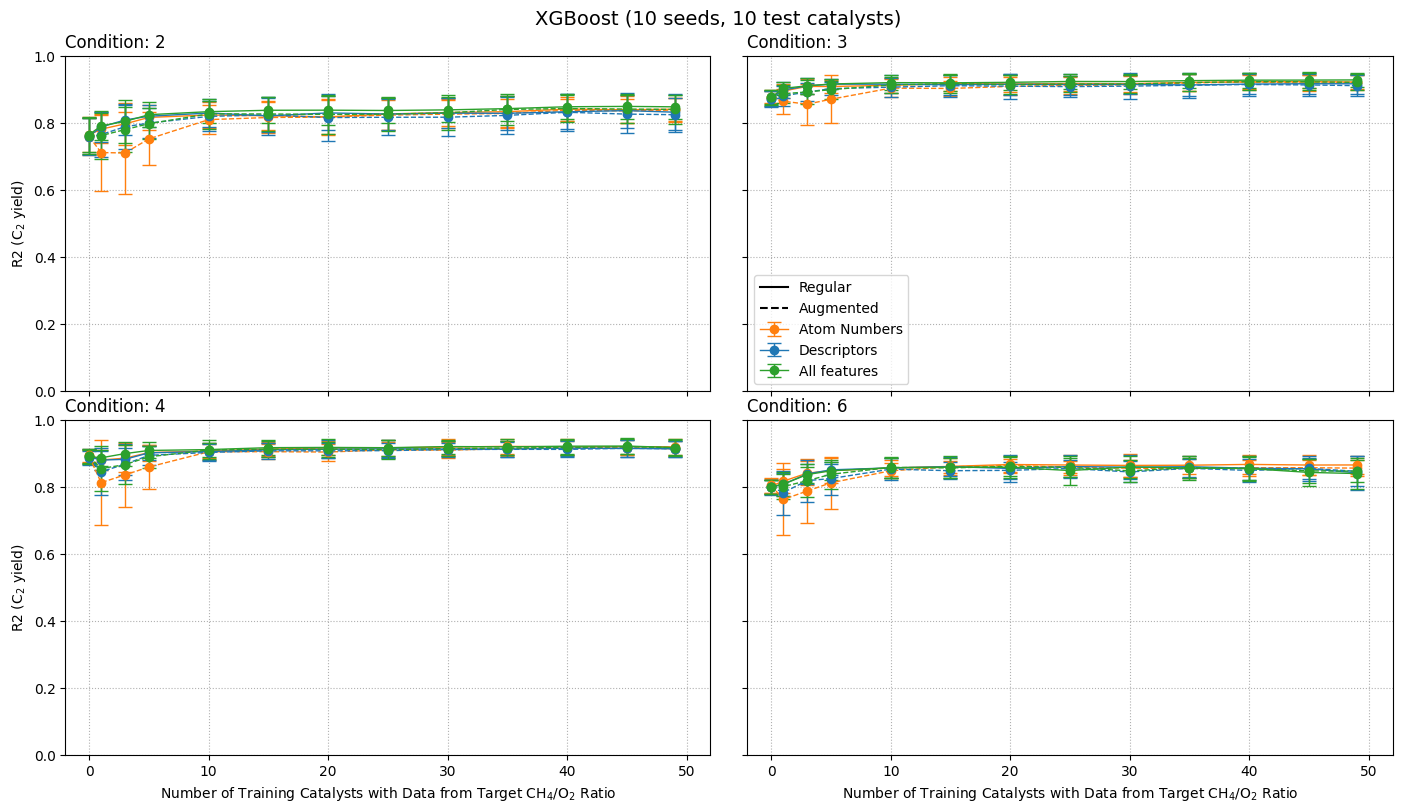

Plotting learning curve for 10 seeds, 10 test catalysts.


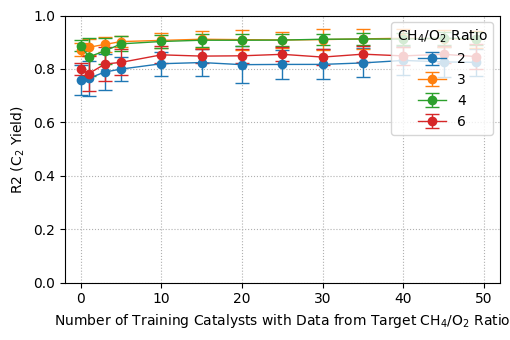

In [9]:
query = None
root = experiments_root / "ratio_ch4o2"
plot_learning_curves_conditions(
    root / "xgb_cv_random_50", 
    measure="mae", 
    ylim=(0.0, 5.0), 
    title="XGBoost", 
    query=query,
    split_strategy="catalyst",
    condition_name="CH$_4$/O$_2$ Ratio",
    train_df=data,
    single_plot_model=("base+descriptors", "yes"),
)
plot_learning_curves_conditions(
    root / "xgb_cv_random_50", 
    measure="r2", 
    ylim=(0.0, 1.0), 
    title="XGBoost", 
    query=query,
    split_strategy="catalyst",
    condition_name="CH$_4$/O$_2$ Ratio",
    train_df=data,
    single_plot_model=("base+descriptors", "yes"),
)

### Model selection

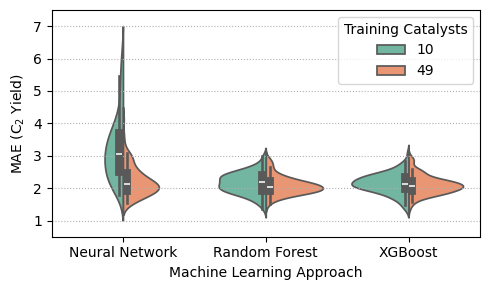

Mean MAE ± standard deviation for...
XGBoost with 10 training catalysts: 2.1510 ± 0.3130
XGBoost with 49 training catalysts: 2.1012 ± 0.2849
Random Forest with 10 training catalysts: 2.1643 ± 0.3245
Random Forest with 49 training catalysts: 2.0850 ± 0.2788
Neural Network with 10 training catalysts: 3.2428 ± 1.0033
Neural Network with 49 training catalysts: 2.2244 ± 0.4683

In training with:
-49 training catalysts
-10 test catalysts
-5-fold cross validation with 10 randomly selected hyperparameter combinations
the average training runtime over 10 seeds was:
XGBoost: 30.65 ± 11.30 seconds
Random Forest: 104.07 ± 25.91 seconds

In training the Neural Network with:
-49 training catalysts
-10 test catalysts
-25 randomly selected hyperparameter combinations
the average training runtime over 100 seeds was:
Per run: 1839.32 ± 858.98 seconds
Per model: 73.57 ± 75.52 seconds


In [10]:
# Violin plot of MAE for n_train_catalysts=49 across models (XGBoost, Random Forest, Neural Network)
n_train_targets = [10, 49]
feature_set = "base+atom_numbers+support"
# feature_set = "base+descriptors"
augmentation = "no"
# augmentation = "yes"

def _load_and_filter_metric(path, feature_sets, augmentations, n_train_targets, metric):
    results_df = load_gathered_results(path)
    results_df["n_train_catalysts"] = results_df["n_train_catalysts"] + results_df["n_val_catalysts"]
    results_df = results_df.drop(columns=["n_val_catalysts"])
    results_df = results_df[
        (results_df["feature_set"].isin(feature_sets)) &
        (results_df["augmentation"].isin(augmentations)) &
        (results_df["n_train_catalysts"].isin(n_train_targets))
    ]
    return results_df[metric].reset_index()

# xgboost
df_xgb = _load_and_filter_metric(experiments_root / "split_catalyst" / "xgb_cv_random_50", [feature_set], [augmentation], n_train_targets, ["mae", "n_train_catalysts"])
df_xgb["strategy"] = "XGBoost"

# random forest
df_rf = _load_and_filter_metric(experiments_root / "RF" / "rf_cv_rf_50", [feature_set], [augmentation], n_train_targets, ["mae", "n_train_catalysts"])
df_rf["strategy"] = "Random Forest"

# neural network
df_nn = _load_and_filter_metric(experiments_root / "NN" , [feature_set], [augmentation], n_train_targets, ["mae", "n_train_catalysts"])
df_nn["strategy"] = "Neural Network"

violin_df = pd.concat([df_xgb, df_rf, df_nn], ignore_index=True)

plt.figure(figsize=(5, 3))
order = ["Neural Network", "Random Forest", "XGBoost"]
sns.violinplot(
    data=violin_df, 
    x="strategy", 
    y="mae", 
    order=order, 
    inner="box", 
    palette="Set2",
    hue="n_train_catalysts",
    hue_order=n_train_targets,
    split=True,
)
plt.legend(title="Training Catalysts", loc="upper right")
plt.ylabel("MAE (C$_2$ Yield)")
plt.xlabel("Machine Learning Approach")
plt.title("")
plt.ylim(0.5, 7.5)
plt.grid(True, axis="y", linestyle=":")
plt.tight_layout()
if store_figures:
    _fm = lambda s: s.replace("base+", "").replace("+support", "").replace(" ", "_").lower()
    figures_root.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_root / f"model_selection_violin_mae_{_fm(feature_set)}_{'aug' if augmentation == 'yes' else 'no_aug'}.png")
plt.show()
# print the variance for each model
print("Mean MAE ± standard deviation for...")
for df in [df_xgb, df_rf, df_nn]:
    for n_train_catalysts in n_train_targets:
        strat = df["strategy"].iloc[0]
        var = df[df["n_train_catalysts"] == n_train_catalysts]["mae"].std()
        mean = df[df["n_train_catalysts"] == n_train_catalysts]["mae"].mean()
        print(f"{strat} with {n_train_catalysts} training catalysts: {mean:.4f} ± {var:.4f}")

# print runtime
xgb_time = pd.read_csv(experiments_root / "timings" / "xgb_cv_random_10" / "timings.csv")
rf_time = pd.read_csv(experiments_root / "timings" / "rf_cv_rf_10" / "timings.csv")
print("\nIn training with:\n-49 training catalysts\n-10 test catalysts\n-5-fold cross validation with 10 randomly selected hyperparameter combinations\nthe average training runtime over 10 seeds was:")
print(f"XGBoost: {xgb_time['training_time'].mean():.2f} ± {xgb_time['training_time'].std():.2f} seconds")
print(f"Random Forest: {rf_time['training_time'].mean():.2f} ± {rf_time['training_time'].std():.2f} seconds")
# for nn
nn_time = pd.read_csv(experiments_root / "timings" / "nn" / "timings.csv")
all_times = nn_time[[f"timing_{i}" for i in range(25)]].values
run_times = all_times.sum(axis=1)
print(f"\nIn training the Neural Network with:\n-49 training catalysts\n-10 test catalysts\n-25 randomly selected hyperparameter combinations\nthe average training runtime over 100 seeds was:")
print(f"Per run: {run_times.mean():.2f} ± {run_times.std():.2f} seconds")
print(f"Per model: {all_times.mean():.2f} ± {all_times.std():.2f} seconds")

### Splitting strategies

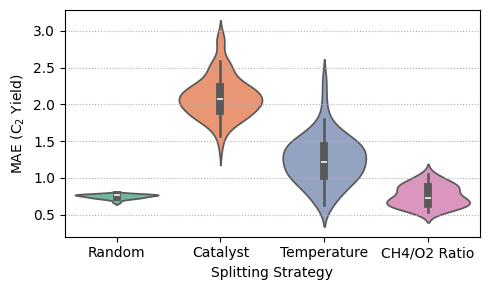

Mean MAE ± standard deviation for...
Random split: 0.7481 ± 0.0292
Catalyst split: 2.1012 ± 0.2849
Temperature split: 1.2445 ± 0.3270
CH4/O2 Ratio split: 0.7547 ± 0.1420


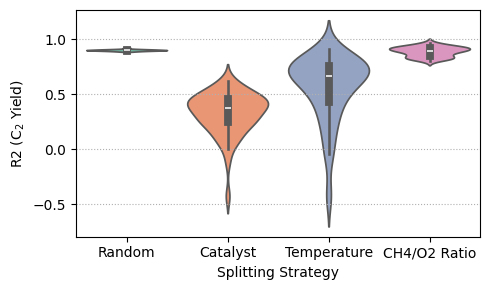

Mean R2 ± standard deviation for...
Random split: 0.8998 ± 0.0071
Catalyst split: 0.3248 ± 0.1924
Temperature split: 0.5562 ± 0.2994
CH4/O2 Ratio split: 0.8869 ± 0.0442


In [11]:
# Violin plot of MAE for n_train_catalysts=49 across split strategies (Atom numbers, no augmentation)
n_train_target = 49
feature_set = "base+atom_numbers+support"
# feature_set = "base+descriptors"
augmentation = "no"
# augmentation = "yes"

# Violin plot for n_train_catalysts=49 across split strategies (Atom numbers, no augmentation)
def _load_and_filter_metric(path, feature_set, augmentation, n_train_target, metric):
    results_df = load_gathered_results(path)
    results_df["n_train_catalysts"] = results_df["n_train_catalysts"] + results_df["n_val_catalysts"]
    results_df = results_df.drop(columns=["n_val_catalysts"])
    results_df = results_df[
        (results_df["feature_set"] == feature_set) &
        (results_df["augmentation"] == augmentation) &
        (results_df["n_train_catalysts"] == n_train_target)
    ]
    return results_df[metric].reset_index()

# random split
df_random = _load_and_filter_metric(experiments_root / "split_random" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "mae")
df_random["strategy"] = "Random"

# catalyst split
df_catalyst = _load_and_filter_metric(experiments_root / "split_catalyst" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "mae")
df_catalyst["strategy"] = "Catalyst"

# temperature split (mean over all conditions per seed)
df_temp = _load_and_filter_metric(experiments_root / "temperature" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "mae")
df_temp["strategy"] = "Temperature"

# CH4/O2 ratio split (mean over all conditions per seed)
df_ratio = _load_and_filter_metric(experiments_root / "ratio_ch4o2" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "mae")
df_ratio["strategy"] = "CH4/O2 Ratio"

violin_df = pd.concat([df_random, df_catalyst, df_temp, df_ratio], ignore_index=True)

plt.figure(figsize=(5, 3))
order = ["Random", "Catalyst", "Temperature", "CH4/O2 Ratio"]
sns.violinplot(data=violin_df, x="strategy", y="mae", order=order, inner="box", palette="Set2", hue="strategy", legend=False)
plt.ylabel("MAE (C$_2$ Yield)")
plt.xlabel("Splitting Strategy")
plt.title("")
plt.grid(True, axis="y", linestyle=":")
plt.tight_layout()
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_root / "splitting_violin_mae_atom_numbers_no_aug.png")
plt.show()
# print the variance for each splitting strategy
print("Mean MAE ± standard deviation for...")
for df in [df_random, df_catalyst, df_temp, df_ratio]:
    strat = df["strategy"].iloc[0]
    mean = df["mae"].mean()
    var = df["mae"].std()
    print(f"{strat} split: {mean:.4f} ± {var:.4f}")


df_random_r2 = _load_and_filter_metric(experiments_root / "split_random" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "r2")
df_random_r2["strategy"] = "Random"

df_catalyst_r2 = _load_and_filter_metric(experiments_root / "split_catalyst" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "r2")
df_catalyst_r2["strategy"] = "Catalyst"

df_temp_r2 = _load_and_filter_metric(experiments_root / "temperature" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "r2")
df_temp_r2["strategy"] = "Temperature"

df_ratio_r2 = _load_and_filter_metric(experiments_root / "ratio_ch4o2" / "xgb_cv_random_50", feature_set, augmentation, n_train_target, "r2")
df_ratio_r2["strategy"] = "CH4/O2 Ratio"

violin_df_r2 = pd.concat([df_random_r2, df_catalyst_r2, df_temp_r2, df_ratio_r2], ignore_index=True)

plt.figure(figsize=(5, 3))
sns.violinplot(data=violin_df_r2, x="strategy", y="r2", order=order, inner="box", palette="Set2", hue="strategy", legend=False)
plt.ylabel("R2 (C$_2$ Yield)")
plt.xlabel("Splitting Strategy")
plt.title("")
plt.grid(True, axis="y", linestyle=":")
plt.tight_layout()
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_root / "splitting_violin_r2_atom_numbers_no_aug.png")
plt.show()
print("Mean R2 ± standard deviation for...")
for df in [df_random_r2, df_catalyst_r2, df_temp_r2, df_ratio_r2]:
    strat = df["strategy"].iloc[0]
    mean = df["r2"].mean()
    var = df["r2"].std()
    print(f"{strat} split: {mean:.4f} ± {var:.4f}")

### Feature set influence

Random Split:


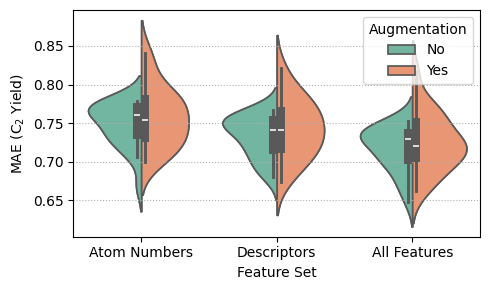

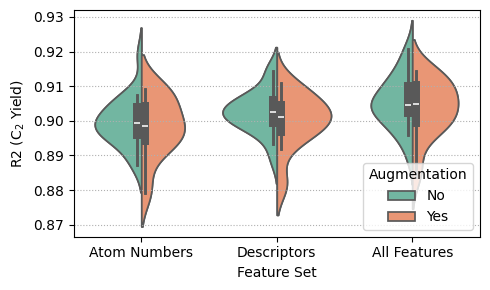

Catalyst Split:


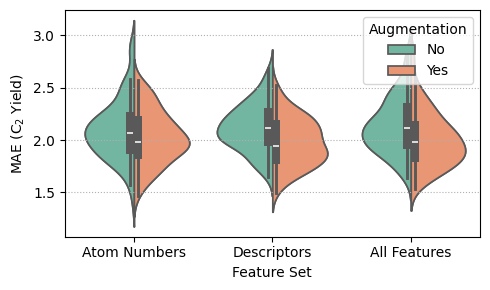

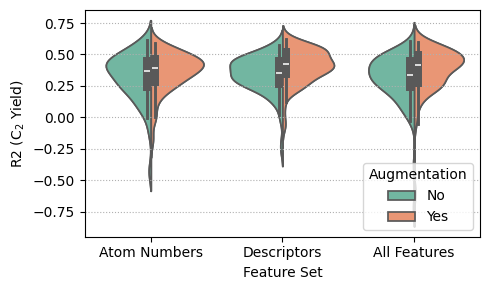

In [12]:
# Violin plots comparing feature sets for random split
print("Random Split:")
feature_sets = [
    ("base+atom_numbers+support", "no"),
    ("base+atom_numbers+support", "yes"),
    ("base+descriptors", "no"), 
    ("base+descriptors", "yes"),
    ("all", "no"),
    ("all", "yes"),
    ]
feature_labels = {
    "base+atom_numbers+support": "Atom Numbers",
    "base+descriptors": "Descriptors",
    "all": "All Features",
}
root = experiments_root / "split_random" / "xgb_cv_random_50"
# MAE
mae_dfs = []
for (fs, aug) in feature_sets:
    df_fs = _load_and_filter_metric(root, fs, aug, 49, "mae")
    df_fs["feature_set"] = feature_labels[fs]
    df_fs["augmentation"] = aug.capitalize()
    mae_dfs.append(df_fs)
violin_fs_mae = pd.concat(mae_dfs, ignore_index=True)

plt.figure(figsize=(5, 3))
order = [feature_labels[fs] for (fs, aug) in feature_sets]
sns.violinplot(data=violin_fs_mae, x="feature_set", y="mae", order=order, inner="box", palette="Set2",
               hue="augmentation", hue_order=["No", "Yes"], split=True)
plt.ylabel("MAE (C$_2$ Yield)")
plt.xlabel("Feature Set")
plt.grid(True, axis="y", linestyle=":")
# plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.legend(loc="upper right", title="Augmentation")
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_root / "feature_set_violin_mae_random.png")
plt.show()

# R2
r2_dfs = []
for (fs, aug) in feature_sets:
    df_fs = _load_and_filter_metric(root, fs, aug, 49, "r2")
    df_fs["feature_set"] = feature_labels[fs]
    df_fs["augmentation"] = aug.capitalize()
    r2_dfs.append(df_fs)
violin_fs_r2 = pd.concat(r2_dfs, ignore_index=True)

plt.figure(figsize=(5, 3))
sns.violinplot(data=violin_fs_r2, x="feature_set", y="r2", order=order, inner="box", palette="Set2",
               hue="augmentation", hue_order=["No", "Yes"], split=True)
plt.ylabel("R2 (C$_2$ Yield)")
plt.xlabel("Feature Set")
plt.grid(True, axis="y", linestyle=":")
plt.tight_layout()
plt.legend(loc="lower right", title="Augmentation")
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_root / "feature_set_violin_r2_random.png")
plt.show()


# Violin plots comparing feature sets for catalyst split
print("Catalyst Split:")
root = experiments_root / "split_catalyst" / "xgb_cv_random_50"
# MAE
mae_dfs = []
for (fs, aug) in feature_sets:
    df_fs = _load_and_filter_metric(root, fs, aug, 49, "mae")
    df_fs["feature_set"] = feature_labels[fs]
    df_fs["augmentation"] = aug.capitalize()
    mae_dfs.append(df_fs)
violin_fs_mae = pd.concat(mae_dfs, ignore_index=True)

plt.figure(figsize=(5, 3))
order = [feature_labels[fs] for (fs, aug) in feature_sets]
sns.violinplot(data=violin_fs_mae, x="feature_set", y="mae", order=order, inner="box", palette="Set2",
               hue="augmentation", hue_order=["No", "Yes"], split=True)
plt.ylabel("MAE (C$_2$ Yield)")
plt.xlabel("Feature Set")
plt.grid(True, axis="y", linestyle=":")
# plt.ylim(0.0, 3.25)
plt.tight_layout()
plt.legend(loc="upper right", title="Augmentation")
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_root / "feature_set_violin_mae_catalyst.png")
plt.show()

# R2
r2_dfs = []
for (fs, aug) in feature_sets:
    df_fs = _load_and_filter_metric(root, fs, aug, 49, "r2")
    df_fs["feature_set"] = feature_labels[fs]
    df_fs["augmentation"] = aug.capitalize()
    r2_dfs.append(df_fs)
violin_fs_r2 = pd.concat(r2_dfs, ignore_index=True)

plt.figure(figsize=(5, 3))
sns.violinplot(data=violin_fs_r2, x="feature_set", y="r2", order=order, inner="box", palette="Set2",
               hue="augmentation", hue_order=["No", "Yes"], split=True)
plt.ylabel("R2 (C$_2$ Yield)")
plt.xlabel("Feature Set")
plt.grid(True, axis="y", linestyle=":")
plt.tight_layout()
plt.legend(loc="lower right", title="Augmentation")
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    plt.savefig(figures_root / "feature_set_violin_r2_random_catalyst.png")
plt.show()

### Shap importances

In [13]:
def plot_shap(
        path: Path, 
        ylim=(1.75, 3.25), 
        ylim_bar=(0.0, 3.5),
        title="", 
        query=None, 
        split_strategy="catalyst",
        top=10,
        single_plot_model=("all", "yes"),
):
    # define function to format strings for filenames
    def _fm(s):
        return s.replace(" ", "_").replace("$_", "").replace("$", "").replace(",", "").lower()
    # load gathered results or gather and store them in a single data frame
    results_df = load_gathered_results(path)
    # compute SHAP values if missing
    if "shap_" + BASE_PROCESS[0] not in results_df.columns:
        results_df = results_df[results_df["n_train_catalysts"] == 3]
        results_df = compute_shap_values(path, results_df, data)
        results_df.to_csv(path / "gathered_results_shap.csv", index=False)
    # combine n_train_catalysts and n_val_catalysts into a single column "n_train_catalysts" (sum of both)
    results_df["n_train_catalysts"] = results_df["n_train_catalysts"] + results_df["n_val_catalysts"]
    results_df = results_df.drop(columns=["n_val_catalysts"])
    if query is not None:
        results_df = results_df.query(query)
    n_seeds = results_df["seed"].nunique()
    n_test_catalysts = results_df["n_test_catalysts"].unique()
    # prepare plots (colors, labels, subplots etc.)
    colors = {
        f"shap_{feature}": FEATURE_COLORS[feature] for feature in ALL_FEATURES
    }
    symbols = {
        f"shap_{feature}": FEATURE_SYMBOLS[feature] for feature in ALL_FEATURES
    }
    labels = {
        ("base+descriptors", "yes"): "Descriptors, augmented",
        ("base+descriptors", "no"): "Descriptors",
        ("base+atom_numbers+support", "yes"): "Atom Numbers, augmented",
        ("base+atom_numbers+support", "no"): "Atom Numbers",
        ("all", "yes"): "All features, augmented",
        ("all", "no"): "All features",
    }
    order = {
        ("base+descriptors", "yes"): 4,
        ("base+descriptors", "no"): 1,
        ("base+atom_numbers+support", "yes"): 3,
        ("base+atom_numbers+support", "no"): 0,
        ("all", "yes"): 5,
        ("all", "no"): 2,
    }
    n_rows = 2
    n_cols = 3
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(9*n_cols, 4*n_rows), sharey=True, sharex=True)
    # fig.suptitle(title + f" SHAP Values", fontsize=16)
    if n_rows > 1:
        axs = axs.flatten()
    # make one plot per feature set and augmentation combination
    for i, ((model_type, feature_set, augmentation), group) in enumerate(results_df.groupby(["model_type", "feature_set", "augmentation"])):
        # get feauture columns
        feature_cols = load_feature_columns(feature_set)
        # extract SHAP values
        shap_cols = [f"shap_{col}" for col in feature_cols]
        res = group.groupby("n_train_catalysts")[shap_cols].agg(["mean", "std"]).reset_index()
        # order shap_cols by mean SHAP value at max n_train_catalysts
        max_n_train = res["n_train_catalysts"].max()
        mean_shap_at_max = {
            col: res.loc[res["n_train_catalysts"] == max_n_train, (col, "mean")].values[0] 
            for col in shap_cols
        }
        shap_cols = sorted(shap_cols, key=lambda col: mean_shap_at_max[col])
        ax = axs[order[(feature_set, augmentation)]]
        for col in shap_cols[:-top:-1]:  # plot only top 10 features
            color = colors[col]
            symbol = symbols[col]
            ax.errorbar(res["n_train_catalysts"], res[(col, "mean")], yerr=res[(col, "std")], label=col[5:], capsize=5, marker=symbol, linestyle='-', color=color, linewidth=1)
        # put legend right of plot (outside)
        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=f"Top-{top} Features")
        ax.set_title(f"{labels[(feature_set, augmentation)]}", loc='left')
        ax.set_xlabel("Number of Training Catalysts")
        ax.set_ylabel("Mean |SHAP Value|")
        ax.grid(True, linestyle=':')
        ax.set_ylim(ylim)
        ax.set_xlim(-2, 52)
        if (feature_set, augmentation) == single_plot_model:
            # plot single plot for specific model with n_train_catalysts vs top features
            _fig, _ax = plt.subplots(figsize=(6, 3))
            for col in shap_cols[:-top:-1]:  # plot only top features
                color = colors[col]
                symbol = symbols[col]
                _ax.errorbar(res["n_train_catalysts"], res[(col, "mean")], yerr=res[(col, "std")], label=col[5:], capsize=5, marker=symbol, linestyle='-', color=color, linewidth=1)
            box = _ax.get_position()
            # _ax.set_position([box.x0, box.y0, box.width * 0.7, box.height])
            _ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=f"Top-{top} Features")
            _ax.set_xlabel("Number of Training Catalysts")
            _ax.set_ylabel("Mean |SHAP Value|")
            _ax.grid(True, linestyle=':')
            _ax.set_ylim(ylim)
            _ax.set_xlim(-2, 52)
            # _ax.set_title(f"SHAP Values per Feature")
            plt.tight_layout()
            # store single plot figure
            if store_figures:
                _fig.savefig(
                    figures_root / 
                    f"shap_{_fm(title)}_{_fm(split_strategy)}_{_fm(labels[single_plot_model])}.png"
                )
            # plot single bar plot for specific model with aggregated SHAP values only for n_train_catalysts = max
            if feature_set == "all":
                _fig2, _ax2 = plt.subplots(figsize=(5, 3))
                max_n_train = res["n_train_catalysts"].max()
                res = res.loc[res["n_train_catalysts"] == max_n_train]
                # aggregate
                for j, (cols, name) in enumerate([
                    (BASE_PROCESS, "Process Conditions"), 
                    (ATOM_NUMBERS+SUPPORT, "Atom+Support IDs"), 
                    (DESCRIPTORS, "Descriptors"),
                ]):
                    
                    _sum = res[[(f"shap_{col}", "mean") for col in cols]].sum(axis=1)
                    _mean = _sum / len(cols)
                    color = COLORS[j]
                    # plot filled bar with hatch for mean per feature group 
                    _ax2.bar(name, _mean, color=color, hatch="//")
                    # plot on top of the first bar a second one alpha for the sum of SHAP values of the feature group
                    _ax2.bar(name, _sum-_mean, bottom=_mean, color=color, alpha=0.5)
                # make invisible bars for legend
                _ax2.bar(name, 0, color="grey", alpha=0.5, label=f"sum over group")
                _ax2.bar(name, 0, color="grey", hatch="///", label=f"mean over group")
                _ax2.legend()
                # rotate x labels
                _ax2.set_xticklabels(_ax2.get_xticklabels(), rotation=7, ha='center')
                _ax2.set_title(f"SHAP Values per Feature Group")
                _ax2.set_ylabel("Mean |SHAP Value|")
                _ax2.set_ylim(ylim_bar)
                plt.tight_layout()
                if store_figures:
                    _fig2.savefig(
                        figures_root / 
                        f"shap_aggregated_{_fm(title)}_{_fm(split_strategy)}_{_fm(labels[single_plot_model])}.png"
                    )
    # store figure
    if store_figures:
        fig.savefig(
            figures_root / 
            f"shap_{_fm(title)}_{_fm(split_strategy)}.png"
        )
    # show figure
    plt.show()
    return

def plot_shap_conditions(
        path: Path, 
        ylim=(1.75, 3.25), 
        title="", 
        query=None, 
        split_strategy="catalyst",
        top=10,
        condition_name="Condition",
        model=("all", "yes"),
):
    # load gathered results or gather and store them in a single data frame
    results_df = load_gathered_results(path)
    # compute SHAP values if missing
    if "shap_" + BASE_PROCESS[0] not in results_df.columns:
        results_df = results_df[results_df["n_train_catalysts"] == 3]
        results_df = compute_shap_values(path, results_df, data)
        results_df.to_csv(path / "gathered_results_shap.csv", index=False)
    # combine n_train_catalysts and n_val_catalysts into a single column "n_train_catalysts" (sum of both)
    results_df["n_train_catalysts"] = results_df["n_train_catalysts"] + results_df["n_val_catalysts"]
    results_df = results_df.drop(columns=["n_val_catalysts"])
    if query is not None:
        results_df = results_df.query(query)
    n_seeds = results_df["seed"].nunique()
    n_test_catalysts = results_df["n_test_catalysts"].unique()
    # prepare plots (colors, labels, subplots etc.)
    colors = {
        f"shap_{feature}": FEATURE_COLORS[feature] for feature in ALL_FEATURES
    }
    symbols = {
        f"shap_{feature}": FEATURE_SYMBOLS[feature] for feature in ALL_FEATURES
    }
    labels = {
        ("base+descriptors", "yes"): "Descriptors, augmented",
        ("base+descriptors", "no"): "Descriptors",
        ("base+atom_numbers+support", "yes"): "Atom Numbers, augmented",
        ("base+atom_numbers+support", "no"): "Atom Numbers",
        ("all", "yes"): "All features, augmented",
        ("all", "no"): "All features",
    }
    n_conditions = results_df["condition"].nunique()
    # only look at results from specific model condition
    results_df = results_df[
        (results_df["feature_set"] == model[0]) & 
        (results_df["augmentation"] == model[1])
    ]
    n_cols = 2
    n_rows = (n_conditions + 1) // 2
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(9*n_cols, 4*n_rows), sharey=True, sharex=True)
    # fig.suptitle(title + f" SHAP Values", fontsize=16)
    if n_rows > 1:
        axs = axs.flatten()
    # make one plot per feature condition
    for i, ((model_type, condition), group) in enumerate(results_df.groupby(["model_type", "condition"])):
        # get feauture columns
        feature_cols = load_feature_columns(model[0])
        # extract SHAP values
        shap_cols = [f"shap_{col}" for col in feature_cols]
        res = group.groupby("n_train_catalysts")[shap_cols].agg(["mean", "std"]).reset_index()
        # order shap_cols by mean SHAP value at max n_train_catalysts
        max_n_train = res["n_train_catalysts"].max()
        mean_shap_at_max = {
            col: res.loc[res["n_train_catalysts"] == max_n_train, (col, "mean")].values[0] 
            for col in shap_cols
        }
        shap_cols = sorted(shap_cols, key=lambda col: mean_shap_at_max[col])
        ax = axs[i]
        for col in shap_cols[:-top:-1]:  # plot only top 10 features
            color = colors[col]
            symbol = symbols[col]
            ax.errorbar(res["n_train_catalysts"], res[(col, "mean")], yerr=res[(col, "std")], label=col[5:], capsize=5, marker=symbol, linestyle='-', color=color, linewidth=1)
        # put legend right of plot (outside)
        box = ax.get_position()
        ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title=f"Top-{top} Features")
        ax.set_title(f"{condition_name}: {condition}{'°C' if condition_name == 'Temperature' else ''}", loc='left')
        ax.set_xlabel("Number of Training Catalysts")
        ax.set_ylabel("Mean |SHAP Value|")
        ax.grid(True, linestyle=':')
        ax.set_ylim(ylim)
        ax.set_xlim(-2, 52)
    # store figure
    def _fm(s):
        return s.replace(" ", "_").replace("$_", "").replace("$", "").replace(",", "").lower()
    if store_figures:
        plt.savefig(
            figures_root / 
            f"shap_{_fm(condition_name)}_{_fm(title)}_{_fm(split_strategy)}_{_fm(labels[model])}.png"
        )
    # show figure
    plt.show()
    return

##### 1. Random split

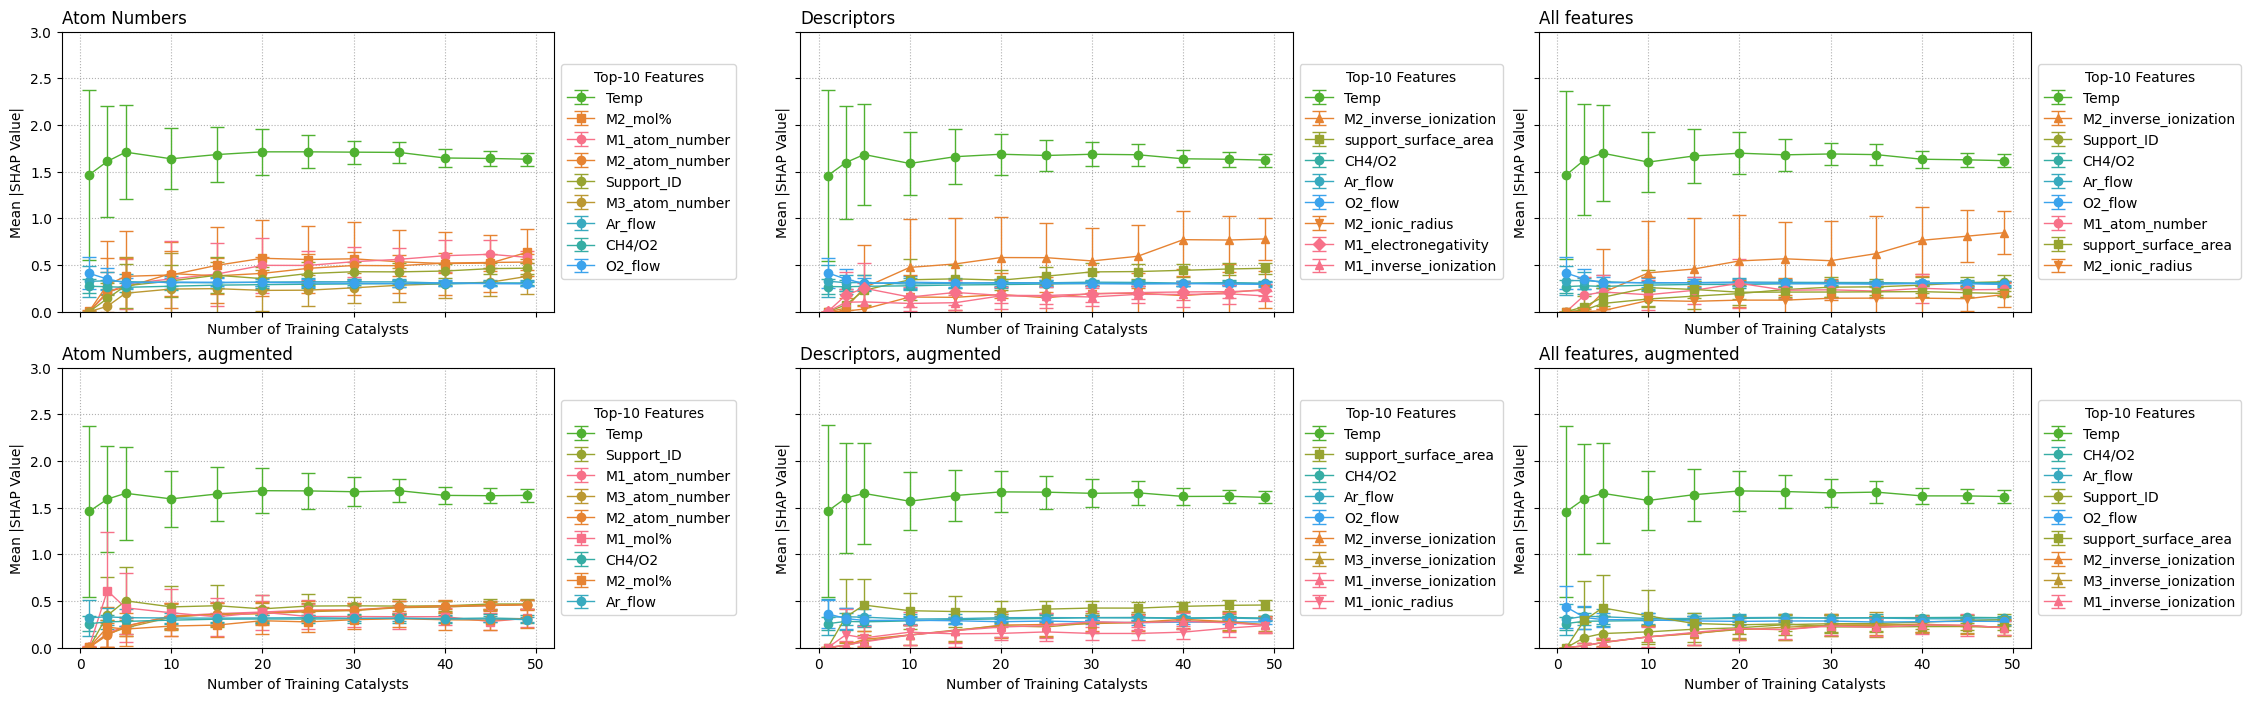

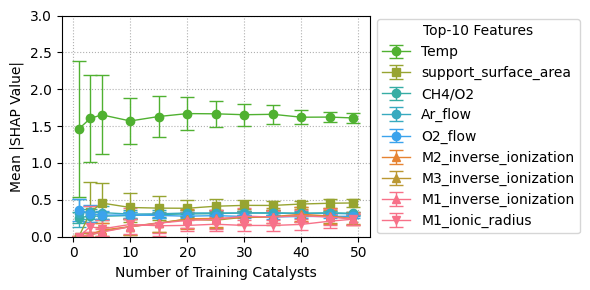

In [14]:
query = None
root = experiments_root / "split_random"
split_strategy = "catalyst_random"
plot_shap(
    root / "xgb_cv_random_50", 
    ylim=(0.0, 3.0), 
    ylim_bar=(0.0, 3.3),
    title="XGBoost", 
    query=query,
    split_strategy=split_strategy,
    top=10,
    single_plot_model=("base+descriptors", "yes"),
    # single_plot_model=("all", "yes"),
)

##### 2. Catalyst split

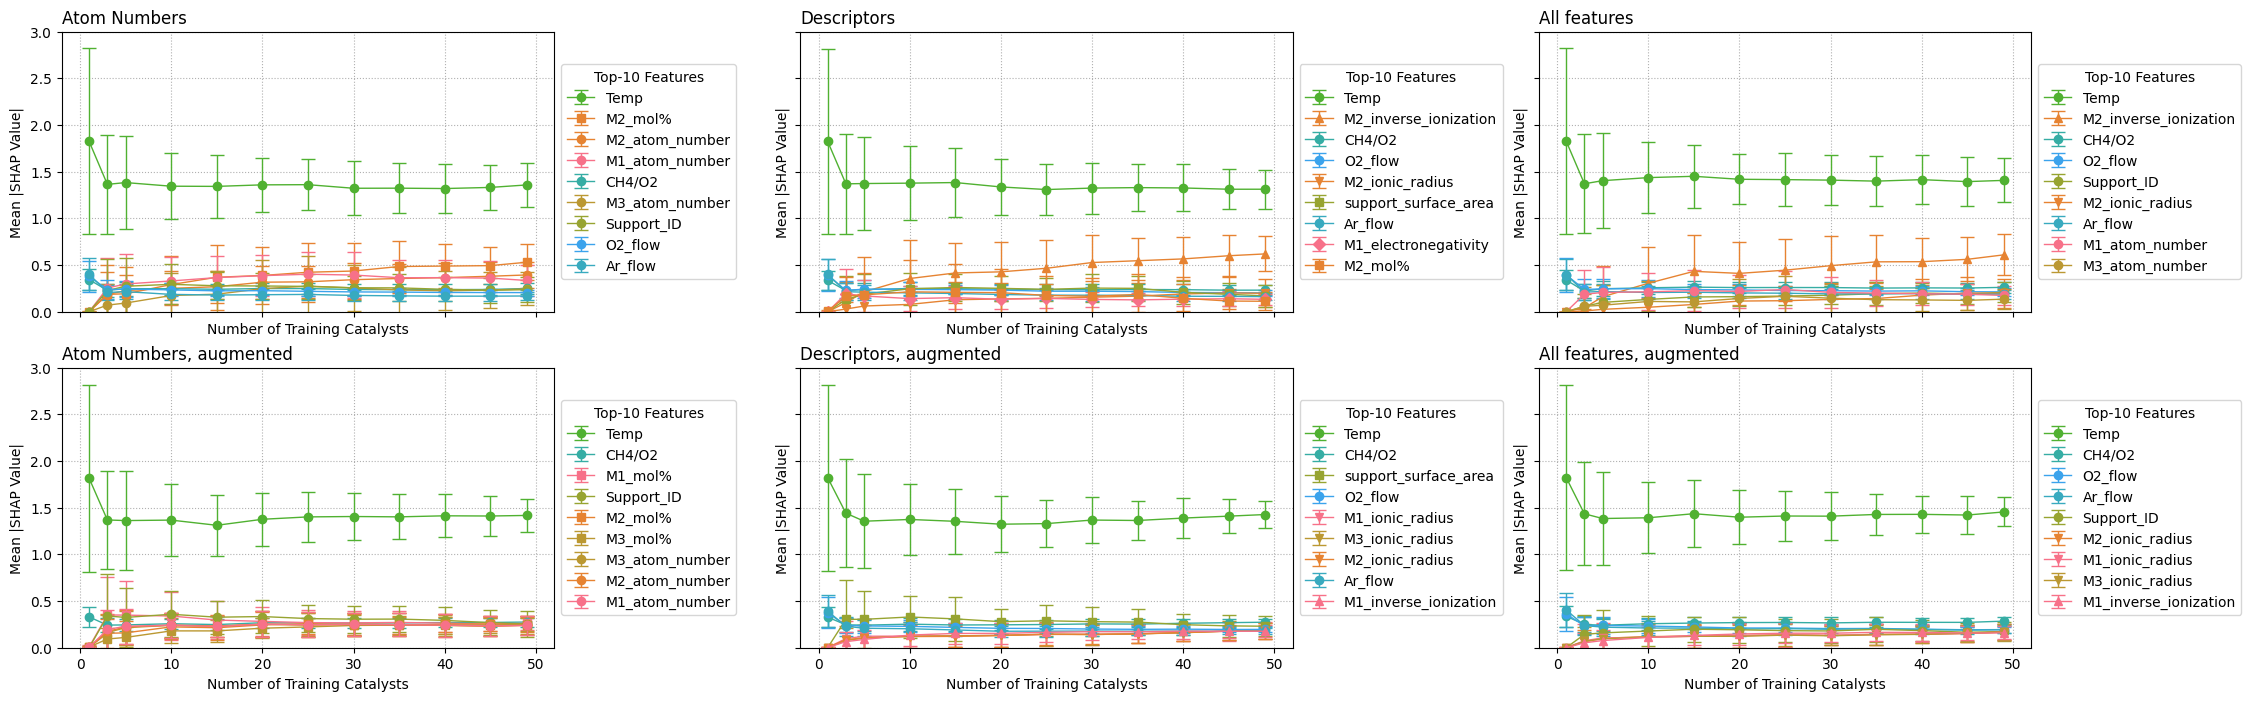

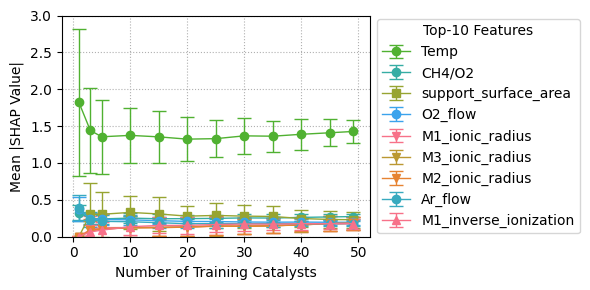

In [15]:
query = None
root = experiments_root / "split_catalyst"
split_strategy = "catalyst"
plot_shap(
    root / "xgb_cv_random_50", 
    ylim=(0.0, 3.0), 
    ylim_bar=(0.0, 2.8),
    title="XGBoost", 
    query=query,
    split_strategy=split_strategy,
    top=10,
    # single_plot_model=("all", "yes"),
    single_plot_model=("base+descriptors", "yes"),
)

##### 3. Temperature

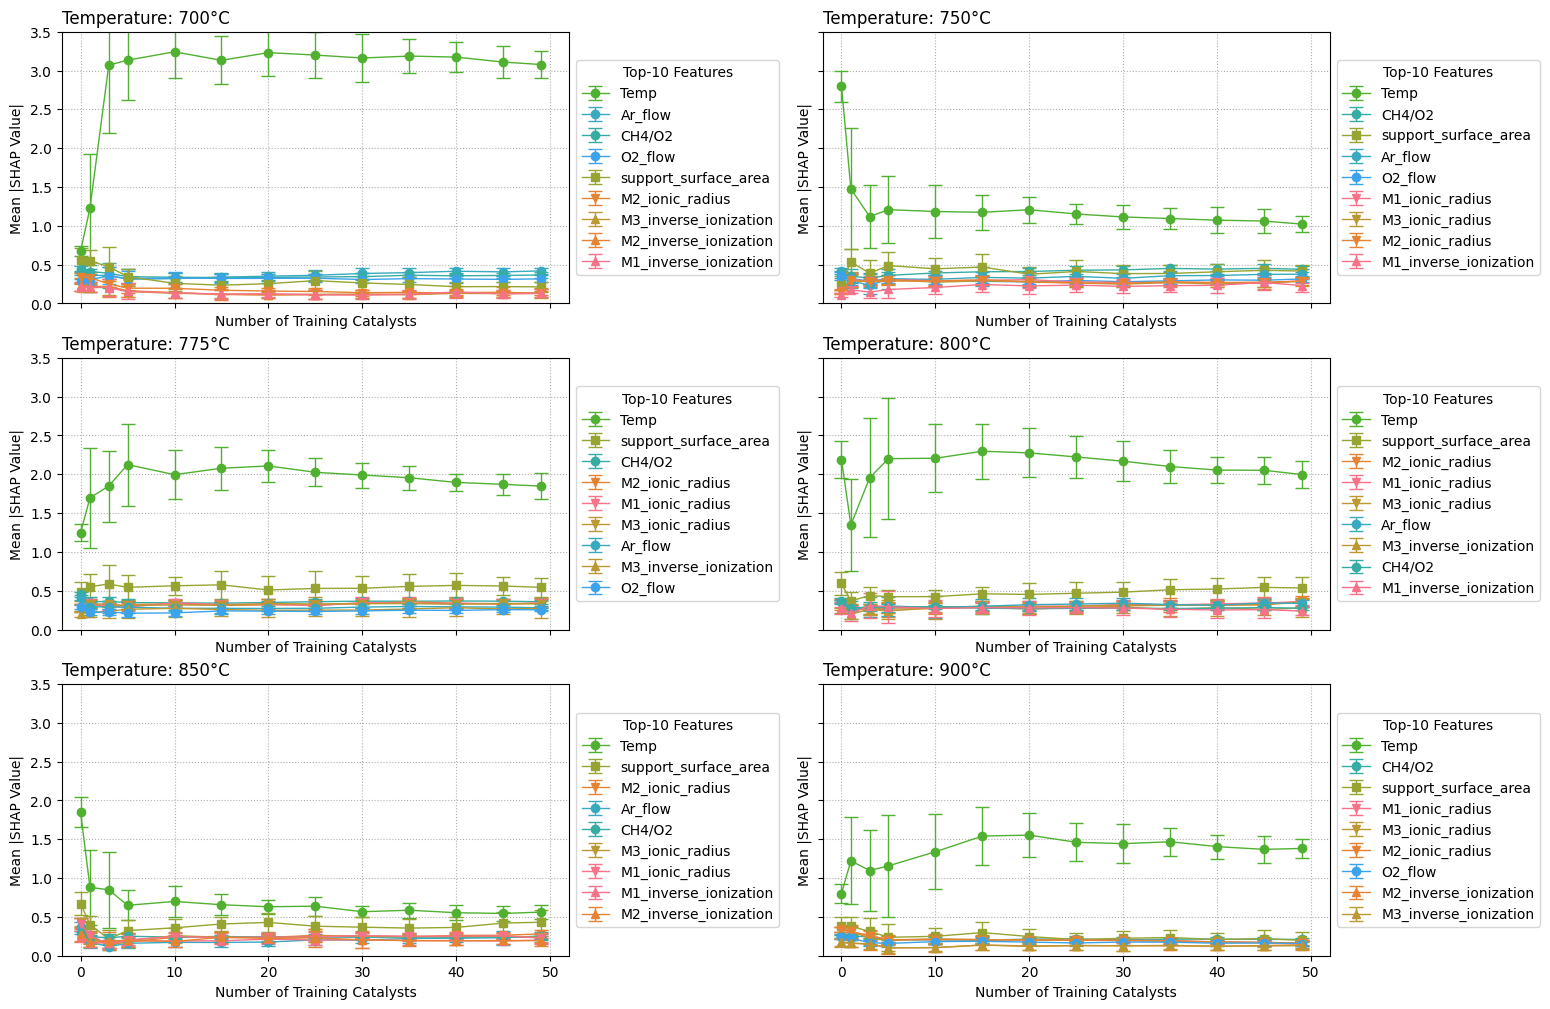

In [16]:
query = None
root = experiments_root / "temperature"
split_strategy = "catalyst"
plot_shap_conditions(
    root / "xgb_cv_random_50", 
    ylim=(0.0, 3.5), 
    title="XGBoost", 
    query=query,
    split_strategy=split_strategy,
    condition_name="Temperature",
    # model=("all", "yes"),
    model=("base+descriptors", "yes"),
)

##### 4. CH4/O2 ratio

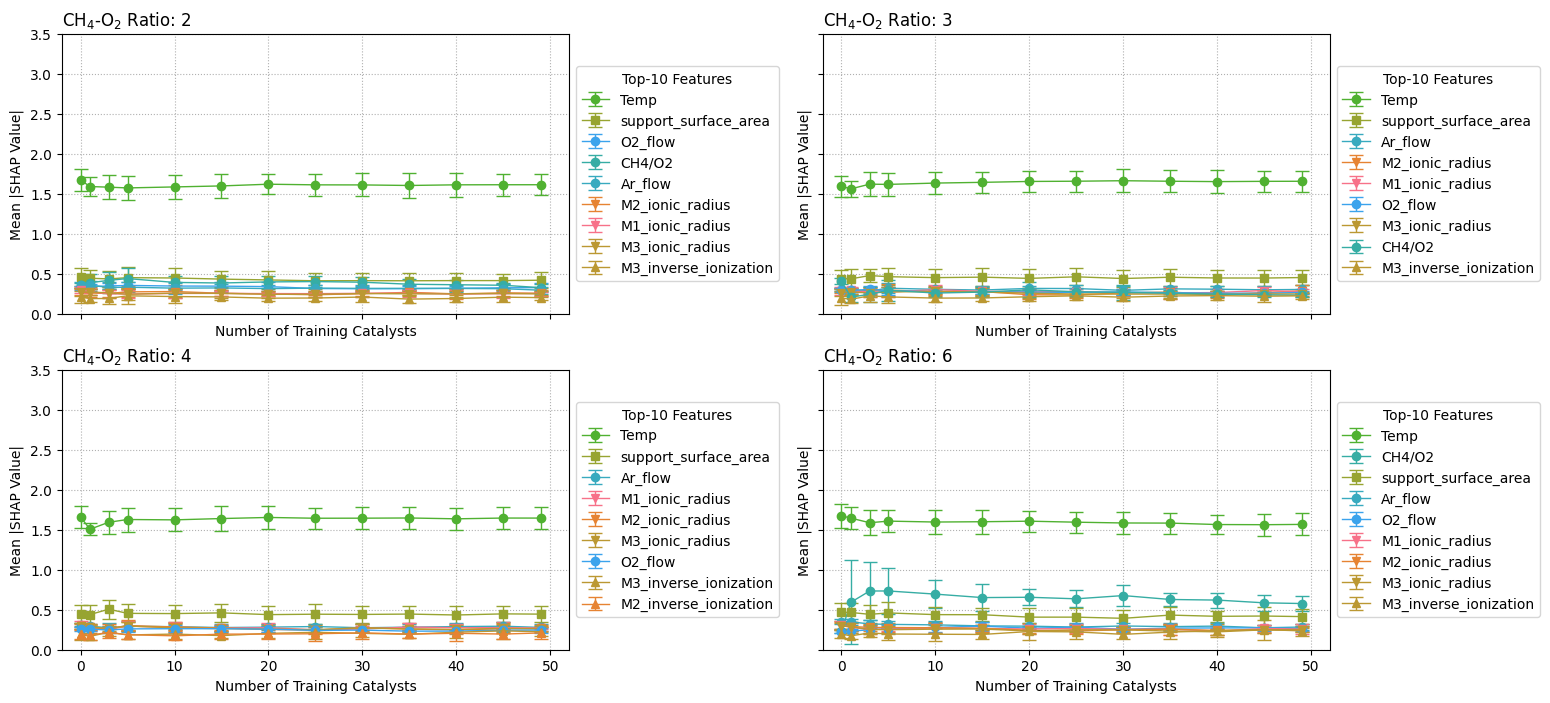

In [17]:
query = None
root = experiments_root / "ratio_ch4o2"
split_strategy = "catalyst"
plot_shap_conditions(
    root / "xgb_cv_random_50", 
    ylim=(0.0, 3.5), 
    title="XGBoost", 
    query=query,
    split_strategy=split_strategy,
    condition_name="CH$_4$-O$_2$ Ratio",
    # model=("all", "yes"),
    model=("base+descriptors", "yes"),
)

# Rankings of test catalysts

In [18]:
from scipy.stats import rankdata

def rank_catalysts(
        path: Path, 
        query=None, 
        single_plot_model=("all", "yes"),
        plot_n = 0,
        C2y_threshold=13,
        n_train_catalysts=49,
        max_n_test_catalysts=10,
        title="",
        train_df=data,
):
    # define function to format strings for filenames
    def _fm(s):
        return s.replace(" ", "_").replace("$_", "").replace("$", "").replace(",", "").replace("°C", "").replace("/", "_").lower()
    # load gathered results or gather and store them in a single data frame
    results_df = load_gathered_results(path)
    # compute max and mean of C2y for each catalyst in test set
    if "test_catalyst_0_C2y_mean" not in results_df.columns:
        results_df = compute_mean_and_max_predictions(path, results_df, train_df, max_n_test_catalysts=max_n_test_catalysts)
        results_df.to_csv(path / "gathered_results_C2y_preds.csv", index=False)
    # combine n_train_catalysts and n_val_catalysts into a single column "n_train_catalysts" (sum of both)
    results_df["n_train_catalysts"] = results_df["n_train_catalysts"] + results_df["n_val_catalysts"]
    results_df = results_df.drop(columns=["n_val_catalysts"])
    if query is not None:
        results_df = results_df.query(query)
    n_seeds = results_df["seed"].nunique()
    n_test_catalysts = results_df["n_test_catalysts"].unique()
    # only use results from specific model condition
    results_df = results_df[
        (results_df["feature_set"] == single_plot_model[0]) & 
        (results_df["augmentation"] == single_plot_model[1]) &
        (results_df["n_train_catalysts"] == n_train_catalysts)
    ]
    
    # visualize different rankings of catalysts based on predicted mean and max C2y for the first 10 seeds
    # infer columns for per-test-catalyst true / predicted mean and max C2y
    mean_cols = [f"test_catalyst_{i}_C2y_mean" for i in range(max_n_test_catalysts)]
    max_cols = [f"test_catalyst_{i}_C2y_max" for i in range(max_n_test_catalysts)]
    pred_mean_cols = [f"test_catalyst_{i}_pred_mean" for i in range(max_n_test_catalysts)]
    pred_max_cols = [f"test_catalyst_{i}_pred_max" for i in range(max_n_test_catalysts)]
    
    # replace missing columns (NaNs) with negative yields
    results_df = results_df.fillna(-10)

    if plot_n > 0:
        # choose seeds to inspect
        seeds = sorted(results_df["seed"].unique())[:min(plot_n, results_df["seed"].nunique())]
        # plot for these seeds (one row per seed)
        fig, axs = plt.subplots(len(seeds), 2, figsize=(10, 5 * len(seeds)), sharey=True, sharex=False, constrained_layout=True)
        fig.suptitle(f"True vs Predicted Ranking ({title})")

        for j, seed in enumerate(seeds):
            row = results_df[results_df["seed"] == seed].iloc[0]
            # assemble arrays (order corresponds to catalyst index order)
            if len(mean_cols) == 0 and len(max_cols) == 0:
                continue
            true_mean = row[mean_cols].astype(float).values if len(mean_cols) else None
            true_max = row[max_cols].astype(float).values if len(max_cols) else None
            pred_mean = row[pred_mean_cols].astype(float).values if len(pred_mean_cols) else None
            pred_max = row[pred_max_cols].astype(float).values if len(pred_max_cols) else None

            n = len(mean_cols) if true_mean is not None else len(max_cols)

            def plot_rank(ax, true_vals, pred_vals, kind="Mean"):
                # ranks: 1 = highest
                true_rank = rankdata(-true_vals, method='average')
                pred_rank = rankdata(-pred_vals, method='average')

                c = [MANY_COLORS[int(tr)] for tr in true_rank]
                # scatter true_rank vs pred_rank for each catalyst and color by rank in true ranking
                ax.scatter(true_rank, pred_rank, s=80, c=c, edgecolors="black")
                lim = (0.5, n + 0.5)
                ax.plot(lim, lim, linestyle="--", color="gray", linewidth=1)
                ax.set_xlim(lim)
                ax.set_ylim(lim)
                ax.set_xlabel("True rank (1 = highest yield)")
                ax.set_ylabel("Predicted rank (1 = highest yield)")
                ax.grid(True, linestyle=":")
                mad = np.mean(np.abs(true_rank - pred_rank))
                ax.set_title(f"{kind} C2y (seed {seed}, MAD: {mad:.2f})")

            if true_mean is not None:
                plot_rank(axs[j, 0], true_mean, pred_mean, kind="Mean")
            else:
                axs[j, 0].set_visible(False)
            if true_max is not None:
                plot_rank(axs[j, 1], true_max, pred_max, kind="Max")
            else:
                axs[j, 1].set_visible(False)

        if store_figures:
            figures_root.mkdir(parents=True, exist_ok=True)
            fig.savefig(figures_root / f"rankings_mean_max_{_fm(title)}.png")
        plt.show()

    # run over all seeds to compute top-3 and outperforming catalysts statistics for max predictions
    ground_truth = results_df[max_cols].values
    predictions = results_df[pred_max_cols].values
    true_rankings = rankdata(-ground_truth, axis=1, method='min')
    predicted_rankings = rankdata(-predictions, axis=1, method='min')
    # compute top-3 proportion
    top_3_true = true_rankings <= 3
    top_3_predicted = predicted_rankings <= 3
    top_3_correct = np.sum(top_3_predicted & top_3_true, axis=1)
    top_3_proportion = np.mean(top_3_correct / np.sum(top_3_true, axis=1))
    print(f"Proportion of correctly identified top-3 catalysts: {top_3_proportion:.2%}")
    # Compute proportion of outperforming catalysts (true max C2y > threshold) that are identified by the model (predicted max C2y > threshold)
    outperforming_true = ground_truth > C2y_threshold
    outperforming_predicted = predictions > C2y_threshold
    n_outperforming_true = np.sum(outperforming_true, axis=1)
    n_outperforming_correct = np.sum(outperforming_predicted & outperforming_true, axis=1)
    if np.sum(n_outperforming_true ) > 0:
        outperforming_proportion = np.sum(n_outperforming_correct / np.where(n_outperforming_true==0, 1, n_outperforming_true))/np.sum(n_outperforming_true>0)  # avoid division by zero and only count cases where there is at least one outperforming catalyst
        print(f"Proportion of correctly identified outperforming catalysts (C2y > {C2y_threshold}): {outperforming_proportion:.2%} ({np.sum(n_outperforming_correct)}/{np.sum(n_outperforming_true)})")
    else:
        print(f"No outperforming catalysts (C2y > {C2y_threshold}) in the test sets.")
    n_outperforming_true_top_3 = np.sum((true_rankings <= 3) & outperforming_true, axis=1)
    n_outperforming_correct_top_3 = np.sum((predicted_rankings <= 3) & outperforming_true, axis=1)
    if np.sum(n_outperforming_true_top_3) > 0:
        outperforming_top_3_proportion = np.sum(n_outperforming_correct_top_3 / np.where(n_outperforming_true_top_3==0, 1, n_outperforming_true_top_3))/np.sum(n_outperforming_true_top_3>0)  # avoid division by zero and only count cases where there is at least one outperforming catalyst
        print(f"Proportion of outperforming catalysts (C2y > {C2y_threshold}) in top-3: {outperforming_top_3_proportion:.2%} ({np.sum(n_outperforming_correct_top_3)}/{np.sum(n_outperforming_true_top_3)})")
    else:
        print(f"No outperforming catalysts (C2y > {C2y_threshold}) in the test sets.")
    # compute Mean Absolute Distance (MAD) of rankings
    MAD = np.mean(np.abs(true_rankings - predicted_rankings))
    print(f"Mean absolute distance of rankings: {MAD}")
    return np.sum(top_3_true, axis=1), top_3_correct, n_outperforming_true, n_outperforming_correct, n_outperforming_true_top_3, n_outperforming_correct_top_3, MAD

##### Catalyst-based split

In [19]:
query = None
root = experiments_root / "split_catalyst"
thresh = 17
cat_split_ranking_results = rank_catalysts(
    root / "xgb_cv_random_50", 
    query=query,
    single_plot_model=("base+descriptors", "yes"),
    plot_n=0,
    C2y_threshold=thresh,
    title="Catalyst Split"
)

Proportion of correctly identified top-3 catalysts: 39.17%
Proportion of correctly identified outperforming catalysts (C2y > 17): 0.00% (0/187)
Proportion of outperforming catalysts (C2y > 17) in top-3: 34.78% (65/176)
Mean absolute distance of rankings: 2.311


##### Temperature-based split

In [20]:
root = experiments_root / "temperature"
temp_split_ranking_results = {}
for temp in [700, 750, 775, 800, 850, 900]:
    print(f"=== Temperature: {temp}°C ===")
    query = f"condition=={temp}"
    temp_split_ranking_results[temp] = rank_catalysts(
        root / "xgb_cv_random_50", 
        query=query,
        single_plot_model=("base+descriptors", "yes"),
        plot_n=0,
        C2y_threshold=thresh,
        title=f"Temperature {temp}°C",
    )
print("=== All Temperatures ===")
temp_split_ranking_results["all"] = rank_catalysts(
    root / "xgb_cv_random_50", 
    query=None,
    single_plot_model=("base+descriptors", "yes"),
    plot_n=0,
    C2y_threshold=thresh,
    title=f"Temperature Split",
)

=== Temperature: 700°C ===
Proportion of correctly identified top-3 catalysts: 53.33%
No outperforming catalysts (C2y > 17) in the test sets.
No outperforming catalysts (C2y > 17) in the test sets.
Mean absolute distance of rankings: 2.39
=== Temperature: 750°C ===
Proportion of correctly identified top-3 catalysts: 66.67%
Proportion of correctly identified outperforming catalysts (C2y > 17): 0.00% (0/1)
Proportion of outperforming catalysts (C2y > 17) in top-3: 100.00% (1/1)
Mean absolute distance of rankings: 1.44
=== Temperature: 775°C ===
Proportion of correctly identified top-3 catalysts: 76.67%
Proportion of correctly identified outperforming catalysts (C2y > 17): 7.14% (1/11)
Proportion of outperforming catalysts (C2y > 17) in top-3: 100.00% (11/11)
Mean absolute distance of rankings: 1.12
=== Temperature: 800°C ===
Proportion of correctly identified top-3 catalysts: 70.00%
Proportion of correctly identified outperforming catalysts (C2y > 17): 15.62% (2/15)
Proportion of outperf

##### CH4/O2-ratio-based split

In [21]:
root = experiments_root / "ratio_ch4o2"
ratio_split_ranking_results = {}
for ratio in [2, 3, 4, 6]:
    print(f"=== CH4/O2 ratio: {ratio} ===")
    query = f"condition=={ratio}"
    ratio_split_ranking_results[ratio] = rank_catalysts(
        root / "xgb_cv_random_50", 
        query=query,
        single_plot_model=("base+descriptors", "yes"),
        plot_n=0,
        C2y_threshold=thresh,
        title=f"CH4/O2 Ratio {ratio}",
    )
print("=== All ratios ===")
ratio_split_ranking_results["all"] = rank_catalysts(
    root / "xgb_cv_random_50", 
    query=None,
    single_plot_model=("base+descriptors", "yes"),
    plot_n=0,
    C2y_threshold=thresh,
    title=f"Ratio Split",
)

=== CH4/O2 ratio: 2 ===
Proportion of correctly identified top-3 catalysts: 80.00%
Proportion of correctly identified outperforming catalysts (C2y > 17): 53.12% (6/15)
Proportion of outperforming catalysts (C2y > 17) in top-3: 100.00% (14/14)
Mean absolute distance of rankings: 0.94
=== CH4/O2 ratio: 3 ===
Proportion of correctly identified top-3 catalysts: 84.17%
Proportion of correctly identified outperforming catalysts (C2y > 17): 51.19% (7/13)
Proportion of outperforming catalysts (C2y > 17) in top-3: 100.00% (12/12)
Mean absolute distance of rankings: 0.55
=== CH4/O2 ratio: 4 ===
Proportion of correctly identified top-3 catalysts: 94.17%
Proportion of correctly identified outperforming catalysts (C2y > 17): 25.00% (1/4)
Proportion of outperforming catalysts (C2y > 17) in top-3: 100.00% (4/4)
Mean absolute distance of rankings: 0.6
=== CH4/O2 ratio: 6 ===
Proportion of correctly identified top-3 catalysts: 70.00%
No outperforming catalysts (C2y > 17) in the test sets.
No outperform

##### Random split

In [22]:
query = None#"seed<=210"
root = experiments_root / "split_random"
random_split_ranking_results = rank_catalysts(
    root / "xgb_cv_random_50", 
    query=query,
    single_plot_model=("base+descriptors", "yes"),
    plot_n=0,
    C2y_threshold=thresh,
    n_train_catalysts=10,
    max_n_test_catalysts=10,
    title="Random Split",
)

Proportion of correctly identified top-3 catalysts: 98.33%
Proportion of correctly identified outperforming catalysts (C2y > 17): 85.56% (20/24)
Proportion of outperforming catalysts (C2y > 17) in top-3: 100.00% (24/24)
Mean absolute distance of rankings: 0.3


/tmp/ipykernel_631520/2624949210.py:45: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df = results_df.fillna(-10)


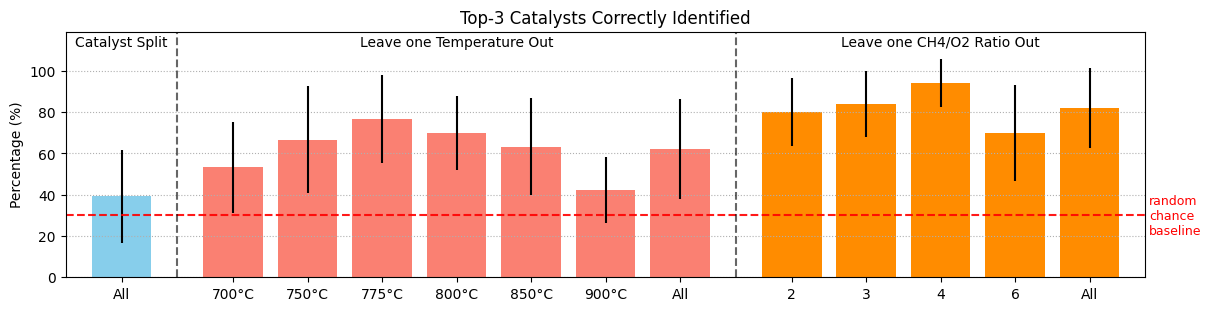

In [23]:
def plot_ranking_comparison_top_3(
    cat_split_results,
    temp_split_results,
    ratio_split_results,
    error_bars=False,
):
    strategies = ["Catalyst Split", "Leave one Temperature Out", "Leave one CH4/O2 Ratio Out"]
    x_labels = [
        "All", 
        "700°C", "750°C", "775°C", "800°C", "850°C", "900°C", "All",
        "2", "3", "4", "6", "All",
    ]
    # helper for safe division
    def process_results(results):
        res = []
        for i, j in [(0, 1), (2, 3), (4, 5)]:
            if results[i].sum() == 0:
                res += [np.nan, np.nan]  # if there are no relevant catalysts, we cannot compute a proportion
            else:
                res += [np.sum(results[j] / np.where(results[i]==0, 1, results[i])) / np.sum(results[i]>0)]  # avoid division by zero and only count cases where there is at least one relevant catalyst
                res += [np.std(results[j][results[i]>0] / results[i][results[i]>0])] # standard deviation of the proportions across seeds, only for cases where there is at least one relevant catalyst
        return res
    cat_split_results = process_results(cat_split_results)
    temp_split_results = {temp: process_results(temp_split_results[temp]) for temp in temp_split_results}
    ratio_split_results = {ratio: process_results(ratio_split_results[ratio]) for ratio in ratio_split_results}
    
    top_3_proportions = [
    cat_split_results[0]*100
    ] + [
    temp_split_results[temp][0]*100 for temp in [700, 750, 775, 800, 850, 900, "all"]
    ] + [
    ratio_split_results[ratio][0]*100 for ratio in [2, 3, 4, 6, "all"]
    ]
    top_3_stds = [
    cat_split_results[1]*100
    ] + [
    temp_split_results[temp][1]*100 for temp in [700, 750, 775, 800, 850, 900, "all"]
    ] + [
    ratio_split_results[ratio][1]*100 for ratio in [2, 3, 4, 6, "all"]
    ]

    fig, axs = plt.subplots(1, 1, figsize=(12, 3), sharex=False, constrained_layout=True)
    colors = ["skyblue", "salmon", "darkorange"]
    bar_colors = [colors[0]] + [colors[1]] * 7 + [colors[2]] * 5

    # create x positions with gaps after the 1st, 8th and 13th bars
    gap_after = [1, 8]  # indices where a gap is inserted before that index
    gap_size = 0.5
    x_positions = np.array([i + sum(1 for g in gap_after if i >= g) * gap_size for i in range(len(x_labels))])
    
    # Top-3 identification
    axs.bar(
        x_positions, 
        top_3_proportions, 
        color=bar_colors, 
        width=0.8 if error_bars else 0.6, 
        yerr=top_3_stds if error_bars else None
    )
    axs.set_ylabel("Percentage (%)")
    axs.set_title("Top-3 Catalysts Correctly Identified")
    axs.set_ylim(0, 119)
    axs.grid(axis='y', linestyle=':')
    axs.axhline(30, color="red", linestyle="--", linewidth=1.5, alpha=0.9)
    axs.text(
        x_positions[-1] + 0.8,
        30,
        "random\nchance\nbaseline",
        color="red",
        va="center",
        ha="left",
        fontsize=9,
    )

    # dashed vertical separators at the gaps
    gap_lines = []
    for gp in gap_after:
        if 0 < gp < len(x_labels):
            mid = 0.5 * (x_positions[gp - 1] + x_positions[gp])
            gap_lines.append(mid)
    for gx in gap_lines:
        axs.axvline(gx, linestyle='--', color='k', alpha=0.6)

    # label the four strategy intervals centered in their regions (place above the axes)
    segments = [(0, 0), (1, 7), (8, 12)]
    label_positions = [(x_positions[s] + x_positions[e]) / 2 for s, e in segments]
    for pos, strat in zip(label_positions, strategies):
        axs.text(
            pos,
            0.93,
            strat,
            ha='center',
            va='bottom',
            transform=axs.get_xaxis_transform(),
            fontsize=10,
            clip_on=False,
        )
    axs.set_xticks(x_positions)
    axs.set_xticklabels(x_labels, rotation=0)
    axs.set_xlim(x_positions[0] - 0.75, x_positions[-1] + 0.75)

    if store_figures:
        figures_root.mkdir(parents=True, exist_ok=True)
        fig.savefig(figures_root / f"ranking_comparison_top_3{'_err' if error_bars else ''}.png")
    plt.show()
    return

plot_ranking_comparison_top_3(
    cat_split_ranking_results,
    temp_split_ranking_results,
    ratio_split_ranking_results,
    error_bars=True,
)

# Virtual catalyst

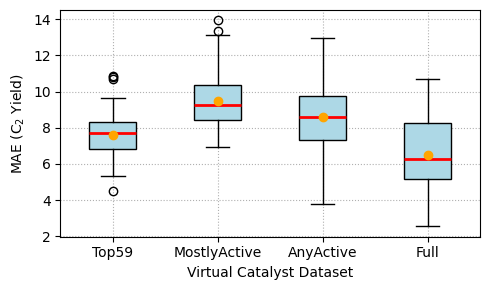

In [3]:
# make boxplot comparing distribution of MAE for the three different data sets of virtual catalysts
sets = {"Top59": "top59", "MostlyActive": "mostly_active", "AnyActive": "any_active", "Full": "full"}
mae_data = []
labels =[]
for label, fs in sets.items():
    df = pd.read_csv(f"../experiments/virtual_cat/{fs}/training_results.csv")
    # take only rows corresponding to the highest number of training catalysts
    max_train_catalysts = df["n_train_catalysts"].max()
    df = df[df["n_train_catalysts"] == max_train_catalysts]
    mae_data.append(df["test_mae"]*100) # convert to percentage
    # make label
    labels += [f"{label}"]
fig, ax = plt.subplots(figsize=(5, 3))
# draw boxplot with error bars for median, std (use beatiful colors and styles)
ax.boxplot(mae_data, tick_labels=labels, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red', linewidth=2), whiskerprops=dict(color='black', linewidth=1), capprops=dict(color='black', linewidth=1))
# also show mean
means = [data.mean() for data in mae_data]
stds = [data.std() for data in mae_data]
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.errorbar(i + 1, mean, fmt='o', color='orange', label='Mean' if i == 0 else "")
ax.set_ylabel("MAE (C$_2$ Yield)")
ax.set_xlabel("Virtual Catalyst Dataset")
# ax.set_title("Virtual Catalyst Dataset MAE")
ax.grid(True, linestyle=':')
plt.tight_layout()
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    fig.savefig(figures_root / f"virtual_catalyst_dataset_mae.png")
plt.show()

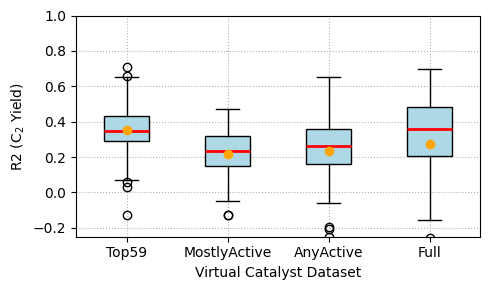

In [4]:

# make boxplot comparing distribution of R2 for the three different data sets of virtual catalysts
r2_data = []
labels =[]
for label, fs in sets.items():
    df = pd.read_csv(f"../experiments/virtual_cat/{fs}/training_results.csv")
    # take only rows corresponding to the highest number of training catalysts
    max_train_catalysts = df["n_train_catalysts"].max()
    df = df[df["n_train_catalysts"] == max_train_catalysts]
    r2_data.append(df["test_r2"])
    # make label
    labels += [f"{label}"]
fig, ax = plt.subplots(figsize=(5, 3))
# draw boxplot with error bars for median, std (use beatiful colors and styles)
ax.boxplot(r2_data, tick_labels=labels, patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'), medianprops=dict(color='red', linewidth=2), whiskerprops=dict(color='black', linewidth=1), capprops=dict(color='black', linewidth=1))
# also show mean
means = [data.mean() for data in r2_data]
stds = [data.std() for data in r2_data]
for i, (mean, std) in enumerate(zip(means, stds)):
    ax.errorbar(i + 1, mean, fmt='o', color='orange', label='Mean' if i == 0 else "")
ax.set_ylabel("R2 (C$_2$ Yield)")
ax.set_xlabel("Virtual Catalyst Dataset")
# ax.set_title("Virtual Catalyst Dataset R2")
ax.set_ylim(-0.25, 1.0)
ax.grid(True, linestyle=':')
plt.tight_layout()
if store_figures:
    figures_root.mkdir(parents=True, exist_ok=True)
    fig.savefig(figures_root / f"virtual_catalyst_dataset_r2.png")
plt.show()

In [5]:
# compute mean predictors for the 100 seeds for the four different virtual catalyst datasets and store results in a csv file
results = []
sets = {"top 59": "top59", "MostlyActive": "mostly_active", "AnyActive": "any_active", "full": "full"}
n_train_per_set = {
    "top 59": [5, 10, 15, 20, 30, 49],
    "MostlyActive": [5, 10, 15, 20, 30, 50, 75, 105],
    "AnyActive": [5, 10, 15, 20, 30, 50, 75, 100, 150, 198],
    "full": [5, 10, 15, 20, 30, 50, 75, 100, 150, 200, 250, 316],
}
for label, fs in sets.items():
    res_path = Path(f"../experiments/virtual_cat/{fs}/mean_predictor_results.csv")
    if not res_path.exists():
        print(f"Computing mean predictor results for {label} dataset...")
        # load dataset
        df = pd.read_csv(f"../Dataset/virtual_catalyst_datasets/{fs}.csv")
        res = [] #  n_train, seed, mean_train_yield, test_mae
        for n_train in tqdm(n_train_per_set[label]):
            for seed in range(100): # for all seeds
                # split
                rng = random.Random(seed)
                model_seed = rng.randint(0, 1000000)
                # Data splitting
                (
                    X_train,
                    y_train,
                    X_val,
                    y_val,
                    X_test,
                    y_test,
                    train_indices,
                    val_indices,
                    test_indices,
                ) = split_data(
                    df,
                    feature_cols=["D1"],
                    target_col="C2y",
                    split_strategy="catalyst",
                    rng=rng,
                    n_train_catalysts=n_train,
                    n_val_catalysts=0,
                    n_test_catalysts=10,
                    return_indices=True,
                    catalyst_name_column="cat_ID",
                )
                # cast to percentages
                y_train *= 100
                y_test *= 100
                # compute mean predictor performance
                res += [n_train, seed, y_train.mean(), np.mean(np.abs(y_test - y_train.mean()))]
        mean_predictor_df = pd.DataFrame(np.array(res).reshape(-1, 4), columns=["n_train_catalysts", "seed", "mean_train_yield", "test_mae"])
        mean_predictor_df.to_csv(res_path, index=False)

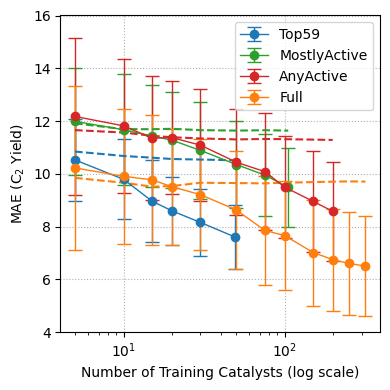

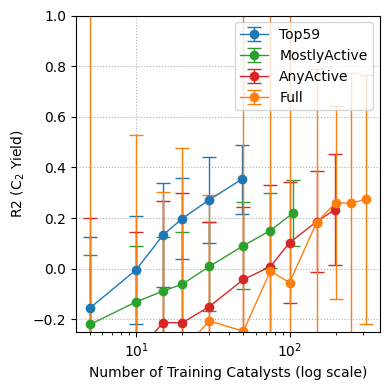

In [13]:
def plot_virt_learning_curve(measure="mae", ylim=(0, 20), sets={"Full": "full", "Top59": "top59"}):
    dfs = {}
    for label, fs in sets.items():
        dfs[label] = pd.read_csv(f"../experiments/virtual_cat/{fs}/training_results.csv")
        if measure == "mae":
            dfs[label]["test_mae"] *= 100 # convert to percentage
    colors = {
        "Top59": COLORS[0],
        "Full": COLORS[1],
        "MostlyActive": COLORS[2],
        "AnyActive": COLORS[3],
    }
    plt.figure(figsize=(4, 4))
    marker = 'o'
    linestyle = '-' # solid line for all
    for key, df in dfs.items():
        res = df.groupby(["n_train_catalysts"])[f"test_{measure}"].agg(["mean", "std"]).reset_index()
        # print(res)
        plt.errorbar(res["n_train_catalysts"], res["mean"], yerr=res["std"], label=key, capsize=5, marker=marker, linestyle=linestyle, color=colors[key], linewidth=1)
    if measure == "mae":
        # plot mean predictors for each set using a dashed line plots for the mean (no error bars and markers)
        for label, fs in sets.items():
            mean_pred_df = pd.read_csv(f"../experiments/virtual_cat/{fs}/mean_predictor_results.csv")
            mean_res = mean_pred_df.groupby(["n_train_catalysts"])["test_mae"].agg(["mean", "std"]).reset_index()
            plt.plot(mean_res["n_train_catalysts"], mean_res["mean"], linestyle='--', color=colors[label], linewidth=1.5)
    plt.xlabel("Number of Training Catalysts (log scale)")
    plt.ylabel(f"{measure.upper()} (C$_2$ Yield)")
    plt.grid(True, linestyle=':')
    plt.ylim(ylim)
    #plt.xlim(-2, 325)
    plt.xscale("log")
    plt.legend(loc="upper right")
    plt.tight_layout()
    # store figure
    def _fm(s):
        return s.replace(" ", "_").lower()
    if store_figures:
        plt.savefig(
            figures_root / 
            f"virtual_catalyst_learning_curve_{_fm(measure)}.png"
        )
    # show figure
    plt.show()

sets = {"Top59": "top59", "MostlyActive": "mostly_active", "AnyActive": "any_active", "Full": "full"}
plot_virt_learning_curve(measure="mae", ylim=(4, 16), sets=sets)
plot_virt_learning_curve(measure="r2", ylim=(-0.25, 1.0), sets=sets)